In [2]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


In [3]:
uv_slope_list=[]
uv_slope_err_list=[]
balmer_ratio_list=[]
balmer_ratio_err_list=[]
redshift_list=[]
plotting_alpha_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    best_SNR=-1
    best_Signal=None
    best_Noise=None
    best_key=None
    for key, dict_value in catalog['lines_fit'].items():

        balmer_decrement_uncertainty=FL.BalmerDecrementUncertainty(dict_value['halpha_flux'],dict_value['halpha_flux_err'],dict_value['hbeta_flux'],dict_value['hbeta_flux_err'])
        balmer_decrement=dict_value['halpha_flux']/dict_value['hbeta_flux']
        snr=abs(balmer_decrement/balmer_decrement_uncertainty)
        if snr>best_SNR:
            best_SNR=snr
            best_Signal=balmer_decrement
            best_Noise=balmer_decrement_uncertainty
            best_key=key

    balmer_ratio_list.append(best_Signal)
    balmer_ratio_err_list.append(best_Noise)
    catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']={key: catalog['lines_fit'][best_key][key] for key in catalog['lines_fit'][best_key].keys()}
    DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)

    uv_slope_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent'])
    uv_slope_err_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent_error'])

    if np.log(best_Signal/2.86)<-0.2:
        plotting_alpha_list.append(0.3)
    else:
        plotting_alpha_list.append(1.0)

    redshift_list.append(catalog['determined_redshift'])


uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)
balmer_ratio_array=np.array(balmer_ratio_list)
balmer_ratio_err_array=np.array(balmer_ratio_err_list)
redshift_array=np.array(redshift_list)
balmer_decrement_array=np.log(balmer_ratio_array/(2.86))
balmer_decrement_uncertainty_array=balmer_ratio_err_array/balmer_ratio_array

In [ ]:
def Calzetti_beta(balmer_decrement):
    """
    Calculate the UV slope (beta) using the Calzetti et al. (1994) relation
    based on the Balmer decrement.

    Parameters:
    balmer_decrement (float or np.ndarray): The Balmer decrement (log(Hα/Hβ ratio)).

    Returns:
    float or np.ndarray: The calculated UV slope (beta).
    """
    beta=1.76*balmer_decrement-1.71

    return beta

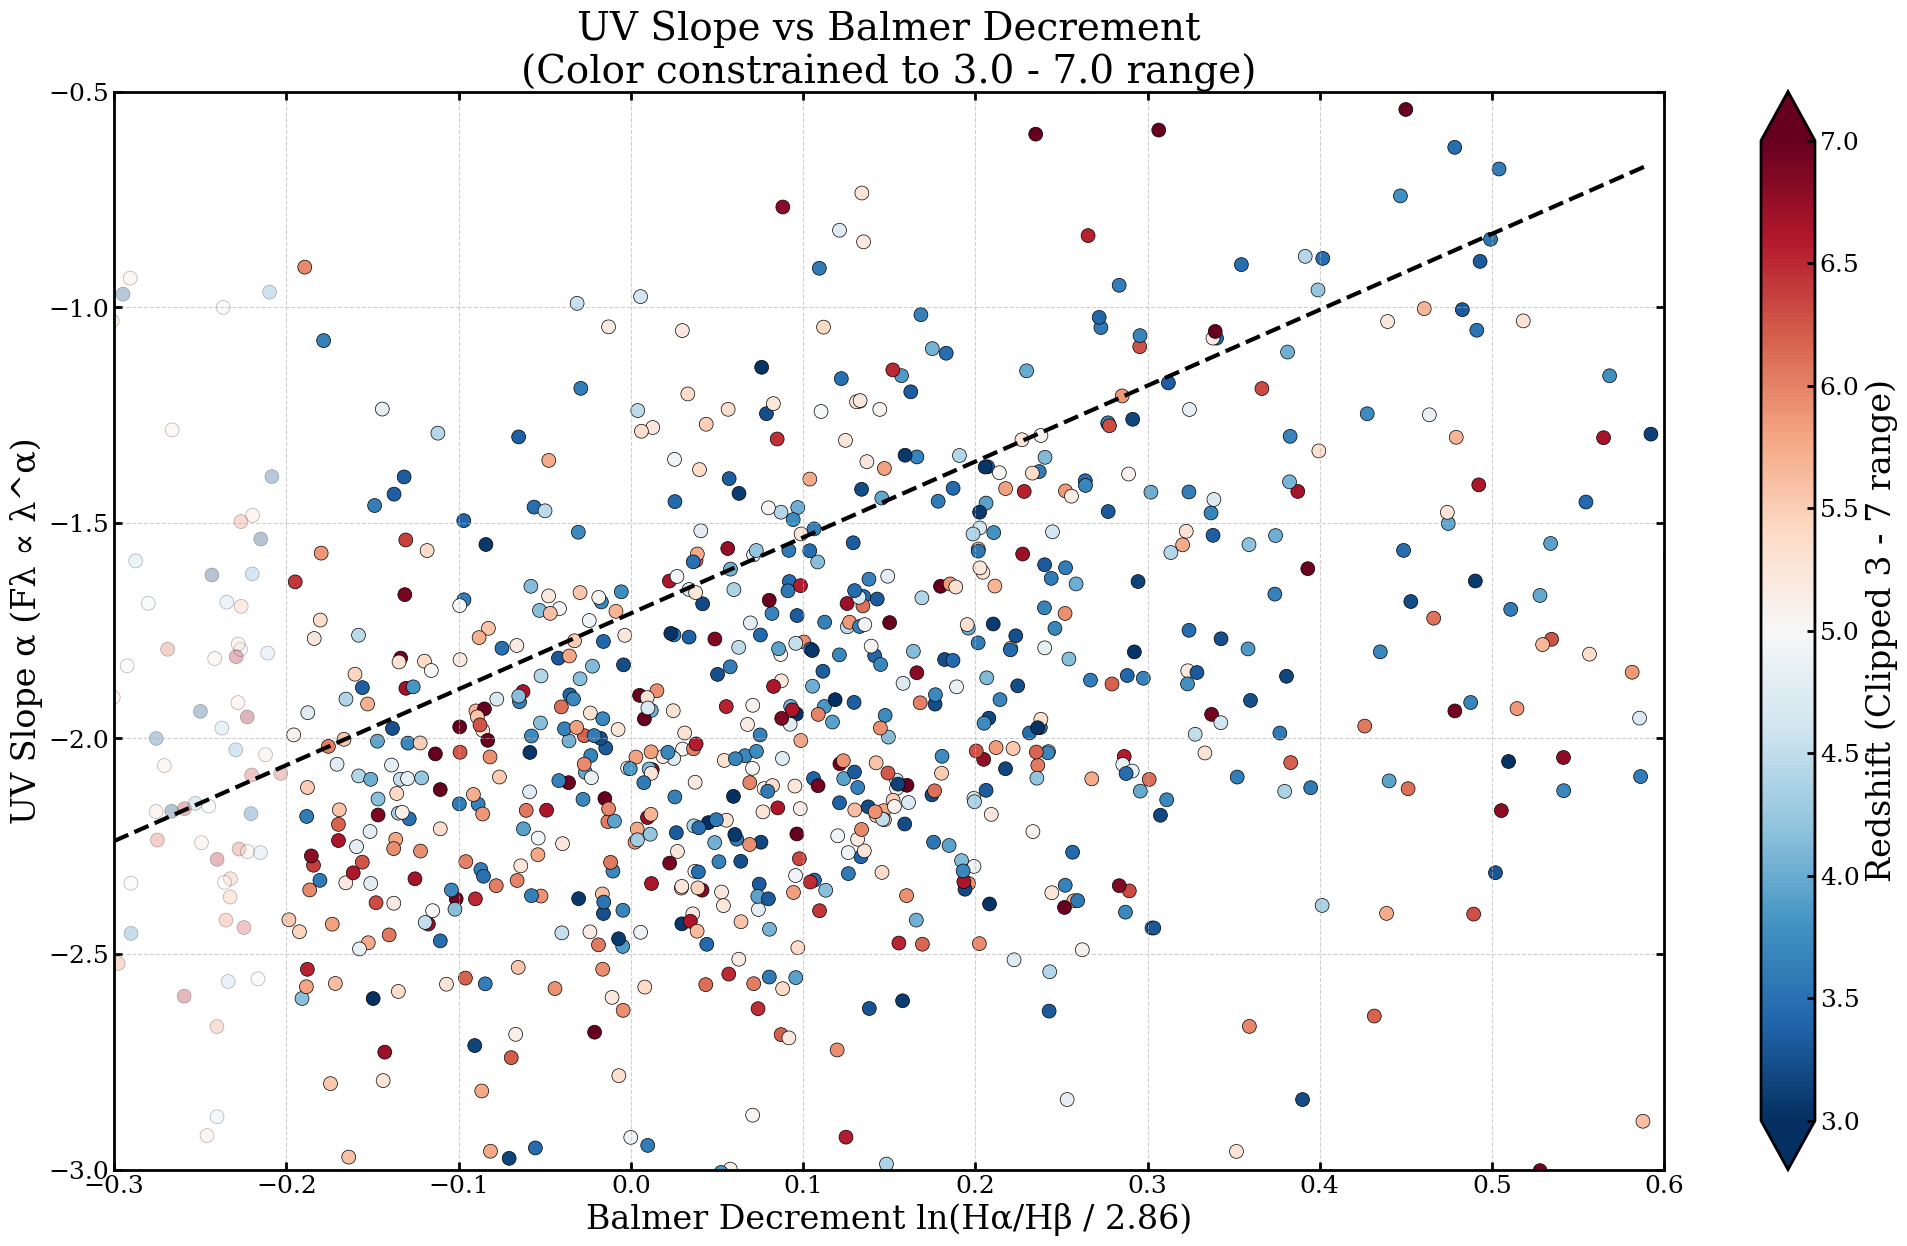

In [7]:
plt.figure(figsize=(25, 14))

# 关键修改：添加 vmin=0.2 和 vmax=1.2
scatter = plt.scatter(balmer_decrement_array,
                        uv_slope_array,
                      c=redshift_array,
                      cmap='RdBu_r',  # 蓝(小) -> 红(大)
                      vmin=3,       # <--- 强制颜色映射下限
                      vmax=7,       # <--- 强制颜色映射上限
                      s=100,
                      alpha=np.array(plotting_alpha_list),
                      edgecolor='k',
                      linewidth=0.5)

# 关键修改：添加 extend='both'
# 这会在颜色条两端显示尖头，表示小于0.2和大于1.2的数据被归类到了边界色
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Redshift (Clipped 3 - 7 range)')
plt.plot(np.arange(-0.3,0.6,0.01), Calzetti_beta(np.arange(-0.3,0.6,0.01)), color='black', linestyle='--', label='Calzetti et al. (1994) Relation',linewidth=3)

plt.xlabel('Balmer Decrement ln(Hα/Hβ / 2.86)')
plt.ylabel('UV Slope α (Fλ ∝ λ^α)')
plt.title('UV Slope vs Balmer Decrement\n(Color constrained to 3.0 - 7.0 range)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.3,0.6)
plt.ylim(-3,-0.5)
# plt.savefig('UV_Slope_vs_Balmer_Decrement_Correction_Clipped_0.2_1.2.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()



Dn_index_list = []
Redshift_list = []

for surveyid_subid, catalog_entry in DJAv4Catalog.catalog_iterator():
    if not catalog_entry['sample_flag']:
        continue
    Dn_index_list.append(catalog_entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['red_flux_density']/catalog_entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['blue_flux_density'])
    Redshift_list.append(catalog_entry['determined_redshift'])

Corrected_Flux_Ratio = np.array(Dn_index_list)
redshift_list = np.array(Redshift_list)

dn_index_conditions=np.array([[0,0.51],[0.51,0.72],[0.72,1.5]])

uv_slope_list=[]
uv_slope_err_list=[]
balmer_decrement_list=[]
balmer_decrement_err_list=[]

redshift_conditions=np.array([[3,3.6],[3.6,4.4],[4.4,5.7],[5.7,7.2]])
def redshift_condition_func(z,redshift_conditions=redshift_conditions):
    for i, condition in enumerate(redshift_conditions):
        if condition[0]<=z<condition[1]:
            return i

color=['b','g','r','c','m','y','k']
colors_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    continuum_dict=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']
    lines_dict=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']

    balmer_ratio_uncertainty=FL.BalmerDecrementUncertainty(lines_dict['halpha_flux'], lines_dict['halpha_flux_err'], lines_dict['hbeta_flux'], lines_dict['hbeta_flux_err'])

    balmer_ratio=lines_dict['halpha_flux']/lines_dict['hbeta_flux']
    balmer_ratio_snr=balmer_ratio/balmer_ratio_uncertainty

    uv_slope=continuum_dict['exponent']
    uv_slope_err=continuum_dict['exponent_error']

    balmer_decrement=np.log(balmer_ratio/2.86)
    redshift_bin_index=redshift_condition_func(catalog['determined_redshift'])
    colors_list.append(color[redshift_bin_index])

    uv_slope_list.append(uv_slope)
    uv_slope_err_list.append(uv_slope_err)
    balmer_decrement_list.append(balmer_decrement)
    balmer_decrement_err_list.append(balmer_ratio_uncertainty / balmer_ratio)

balmer_decrement_array=np.array(balmer_decrement_list)
balmer_decrement_uncertainty_array=np.array(balmer_decrement_err_list)
uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)

group_conditions = [(-0.2,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 6

def dn_condition_func(dn_index):
    for i, (low, high) in enumerate(dn_index_conditions):
        if low < dn_index <= high:
            return i
    return 6
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k


def get_calzetti_curve(x, Rv=4.05):
    """
    Calzetti (2000) Law
    x: 1/lambda [um^-1]
    Return: A_lambda / A_V
    """
    lam_um = 1.0 / x
    k = np.zeros_like(x)

    # 0.12um <= lam < 0.63um (1.58 < x <= 8.33)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    l = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/l - 0.198/l**2 + 0.011/l**3) + Rv

    # 0.63um <= lam <= 2.2um (0.45 <= x < 1.58)
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    l = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/l) + Rv

    # 转换为 A_lambda / A_V = k / Rv
    return k / Rv

def get_mw_ccm89(x, Rv=3.1):
    """
    Milky Way: Cardelli, Clayton, & Mathis (1989)
    x: 1/lambda [um^-1]
    Return: A_lambda / A_V
    """
    # y = x - 1.82
    # a, b coefficients... 简化版实现 UV 部分 (x > 3.3)
    # 为了精确，这里使用完整的 CCM89 UV 段公式
    a = np.zeros_like(x)
    b = np.zeros_like(x)

    # Visible / NIR range (0.3 <= x < 1.1) ... 略过，主要画 UV
    # Optical/UV (1.1 <= x < 3.3)
    mask_opt = (x >= 1.1) & (x < 3.3)
    y = x[mask_opt] - 1.82
    a[mask_opt] = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[mask_opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7

    # UV (3.3 <= x <= 8)
    mask_uv = (x >= 3.3)
    X = x[mask_uv]
    F_a = -0.04473 * (X - 5.9)**2 - 0.009779 * (X - 5.9)**3
    F_b = 0.2130 * (X - 5.9)**2 + 0.1207 * (X - 5.9)**3
    # Only apply F_a, F_b for x >= 5.9
    F_a[X < 5.9] = 0
    F_b[X < 5.9] = 0

    a[mask_uv] = 1.752 - 0.316*X - 0.104/((X - 4.67)**2 + 0.341) + F_a
    b[mask_uv] = -3.090 + 1.825*X + 1.206/((X - 4.67)**2 + 0.263) + F_b

    return a + b / Rv

def get_smc_pei92(x):
    """
    SMC: Pei (1992) Approximation
    SMC has no 2175A bump and is steeper.
    Usually Rv ~ 2.93 or 2.74
    Here we use the provided fitting formula values for Alambda/Av approx
    Or simpler: Gordon et al 2003 SMC Bar.
    Let's use a standard literature approximation for plot comparison.
    Reference: A_lambda / A_V approx
    """
    # Gordon et al. 2003 SMC Bar Average
    # x is 1/micron
    # Data points from literature spline
    # But for smooth plotting, let's use the Pei 1992 parameters (User for A_lambda/E(B-V))
    # A_lambda/A_V = (A_lambda/A_B) * (1 / (1 - 1/Rb)) ... complicated
    # Let's use the Prevot et al. (1984) linear fit often used for SMC
    # k(lam) = 1.39 * x - ...
    # Let's map Calzetti plot visual: SMC is steep linear

    # Using Pei (1992) formula structure:
    # A_lambda / A_V = (1 + sum(a_i / ((lam/lam_i)**ni + (lam_i/lam)**ni))) / (1 + ...)
    # This is too complex to hardcode quickly.

    # We will use the simplified polynomial often used to represent SMC in these plots:
    # y = -4.96 + 2.26*x  (for k, then divide by Rv=2.74)
    # A_lambda/A_V approx
    Rv_smc = 2.74
    k_smc = -4.96 + 2.26 * x + 1.1 # 1.1 is adjustment to make V=0 approx correct for fitting
    # A better spline representation of SMC (Gordon 2003):
    y = np.zeros_like(x)
    # Optical part
    mask = x < 3.3
    y[mask] = -2.3 + 1.85 * x[mask] # Crude approx
    # UV part
    mask = x >= 3.3
    # SMC is roughly linear in UV
    y[mask] = (x[mask] * 2.1 - 4.2)
    # Normalize to passing 1 at x=1.8 (V band)
    # At x=1.8, A/Av = 1.
    # Let's use the explicit CCM curve with Rv=2.0 (Simulates SMC steepness without bump)
    # Or just load theoretical curve.

    # **BEST APPROACH FOR PLOT**: Use Pei (1992) analytical formula for extinction
    # Coefficients for SMC
    a = [185, 27, 0.005, 0.010, 0.012, 0.030]
    w = [0.042, 0.08, 0.22, 9.7, 18, 25] # lambda_i
    b = [90, 5.5, -1.95, -1.95, -1.80, 0.0]
    n = [2.0, 4.0, 2.0, 2.0, 2.0, 2.0]

    lam = 1.0 / x
    ext_sum = 0
    for i in range(6):
        term = a[i] / ((lam/w[i])**n[i] + (w[i]/lam)**n[i] + b[i])
        ext_sum += term

    # We need to normalize this. This formula gives extinction cross section or similar.
    # Calculate at V (0.55um) and B (0.44um)
    def calc_pei(l_val):
        val = 0
        for i in range(6):
            val += a[i] / ((l_val/w[i])**n[i] + (w[i]/l_val)**n[i] + b[i])
        return val

    val_V = calc_pei(0.55)
    val_B = calc_pei(0.44)
    # Rb = Av / E(B-V)
    Rv = val_V / (val_B - val_V) # Theoretical Rv for these params (~2.93)

    return ext_sum / val_V # Normalize to A_V=1

1102


Spectrum index 7 has invalid normalization factor. Skipping.


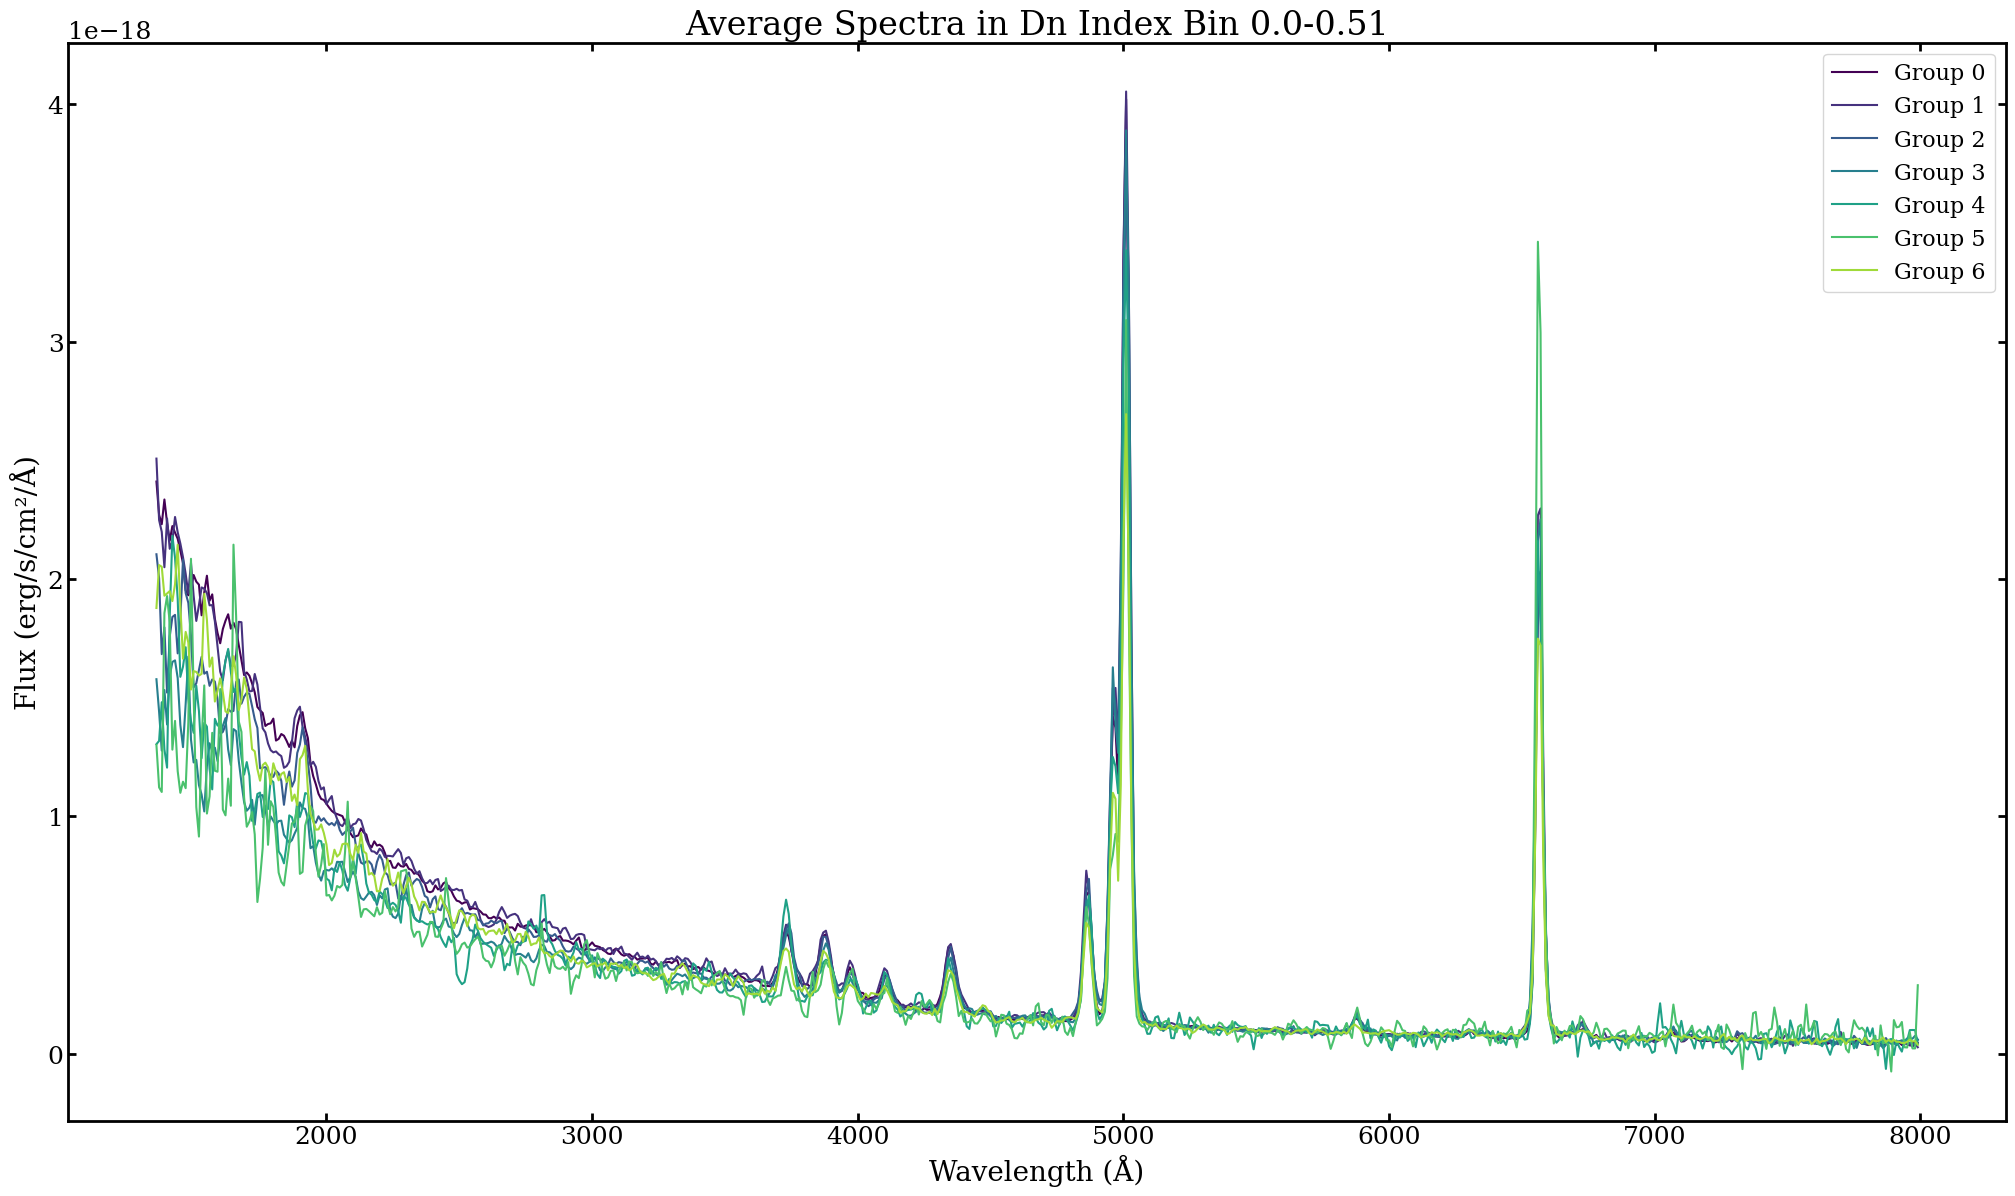

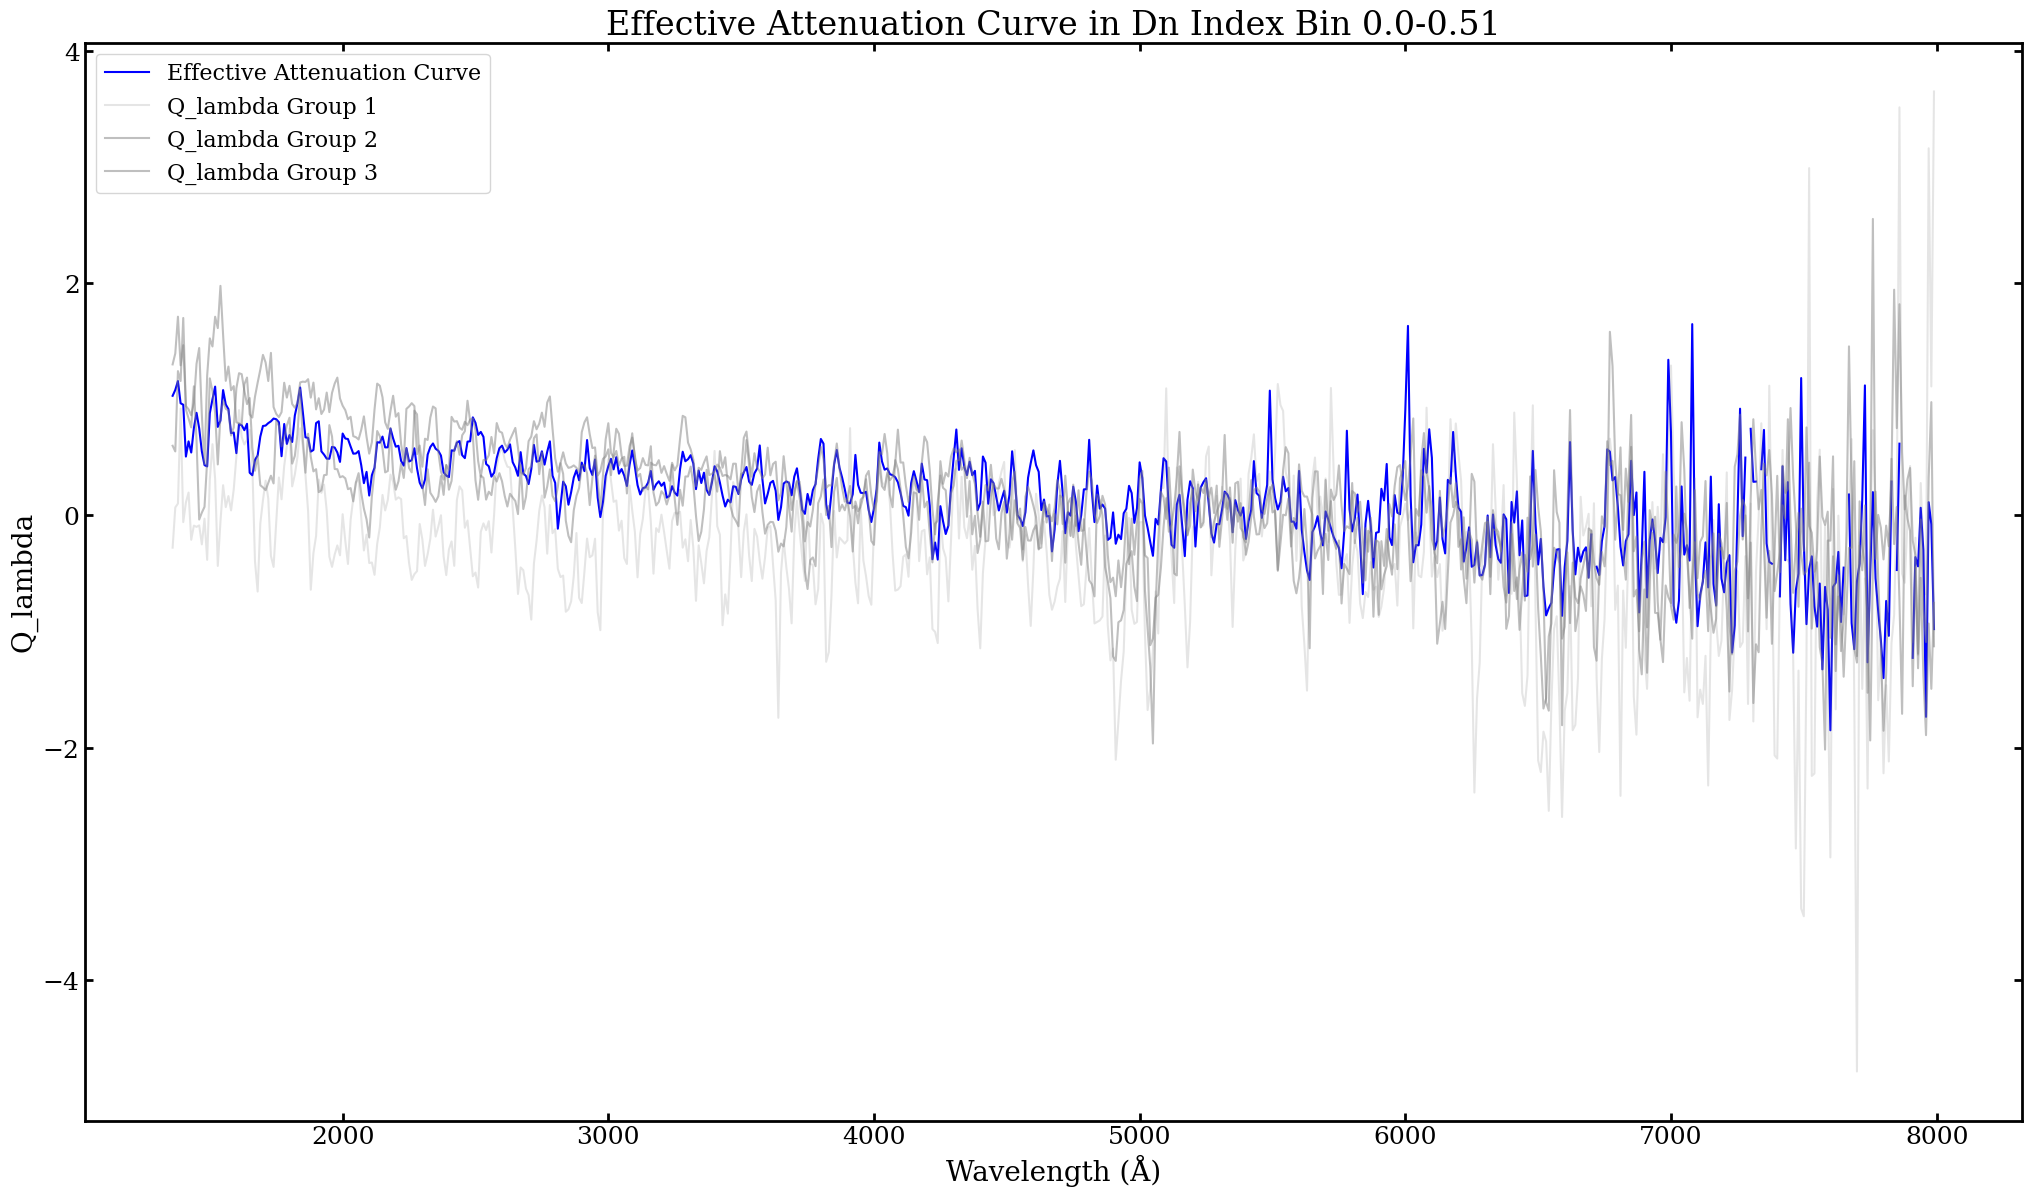

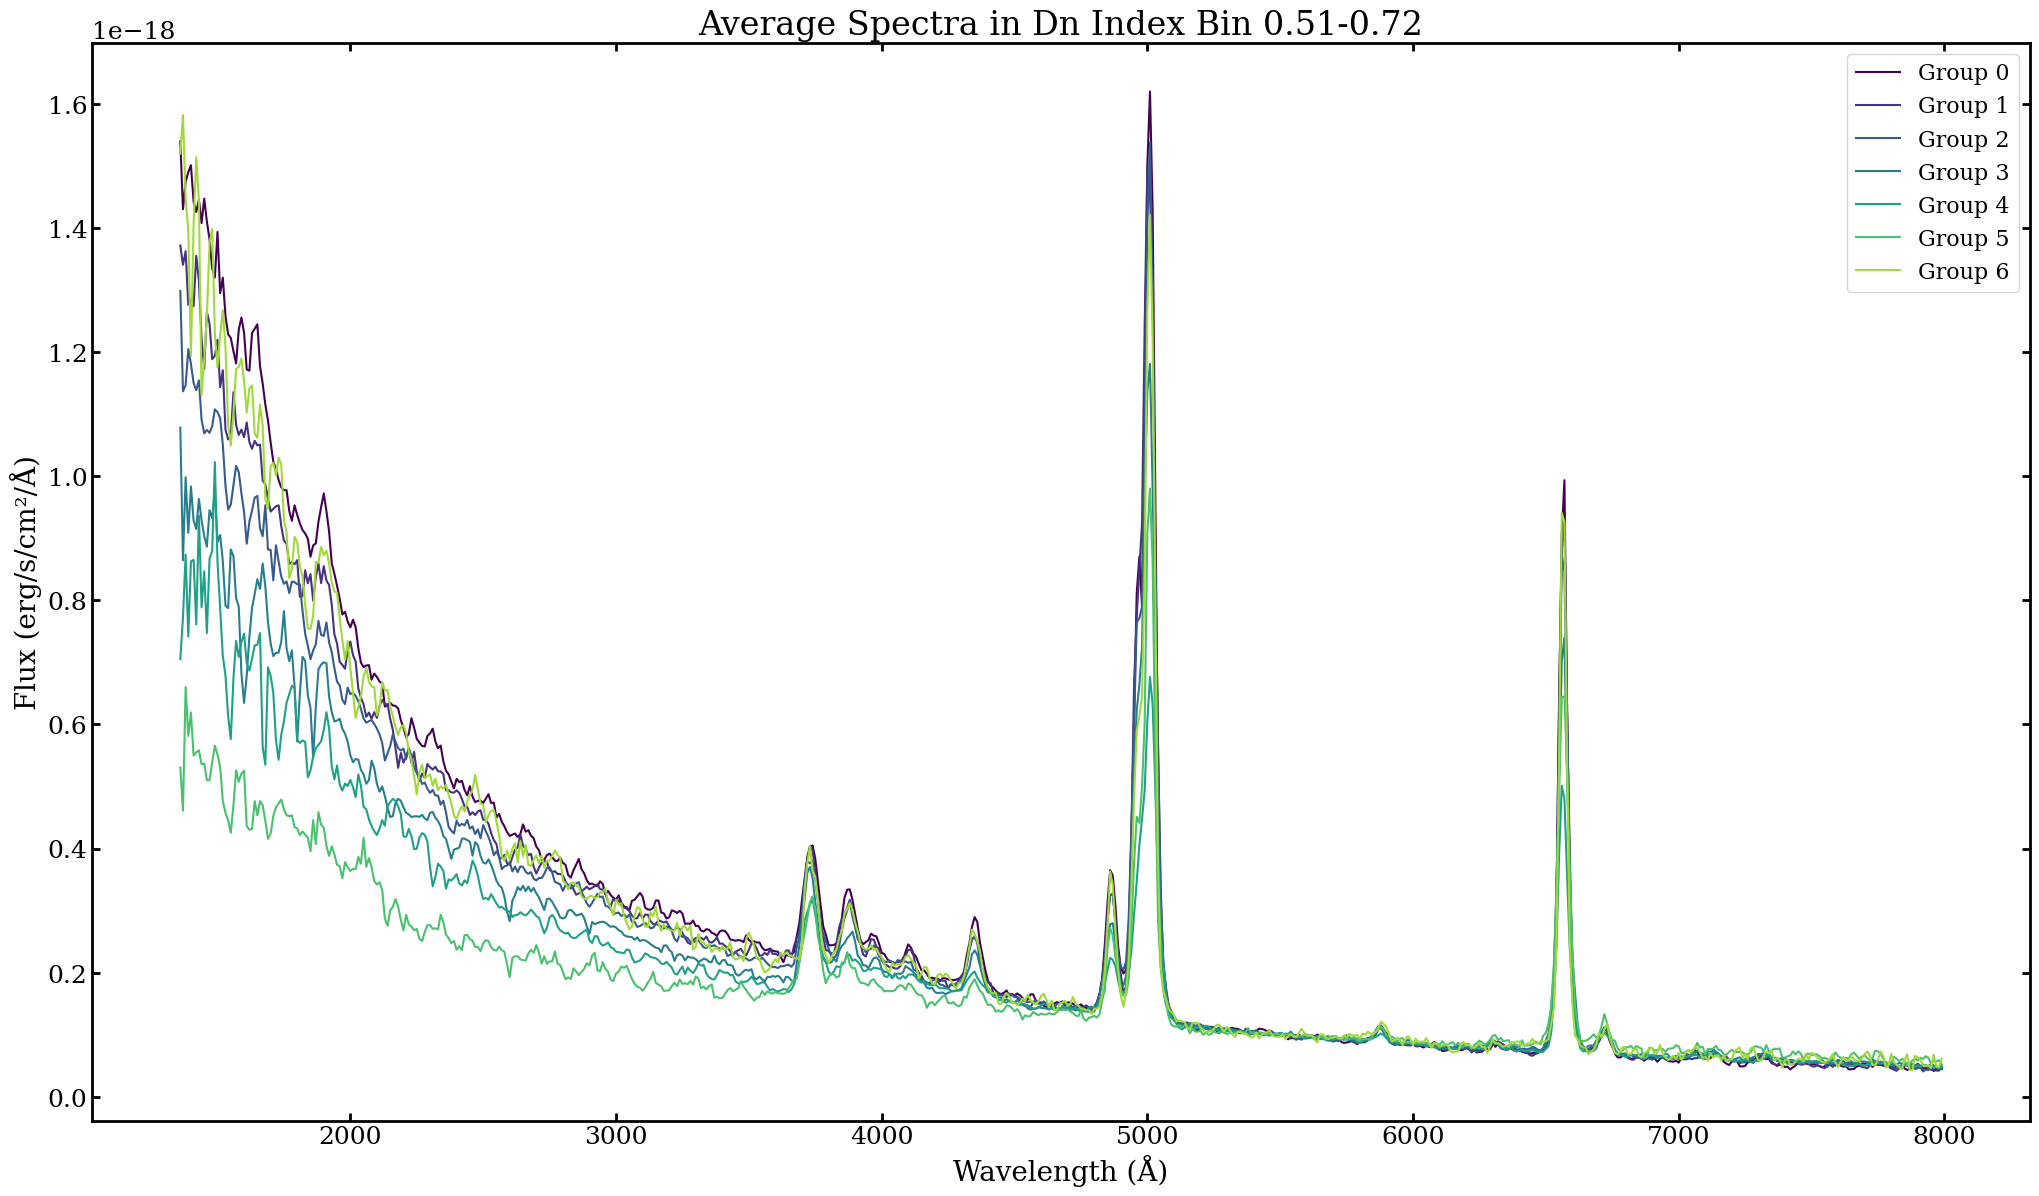

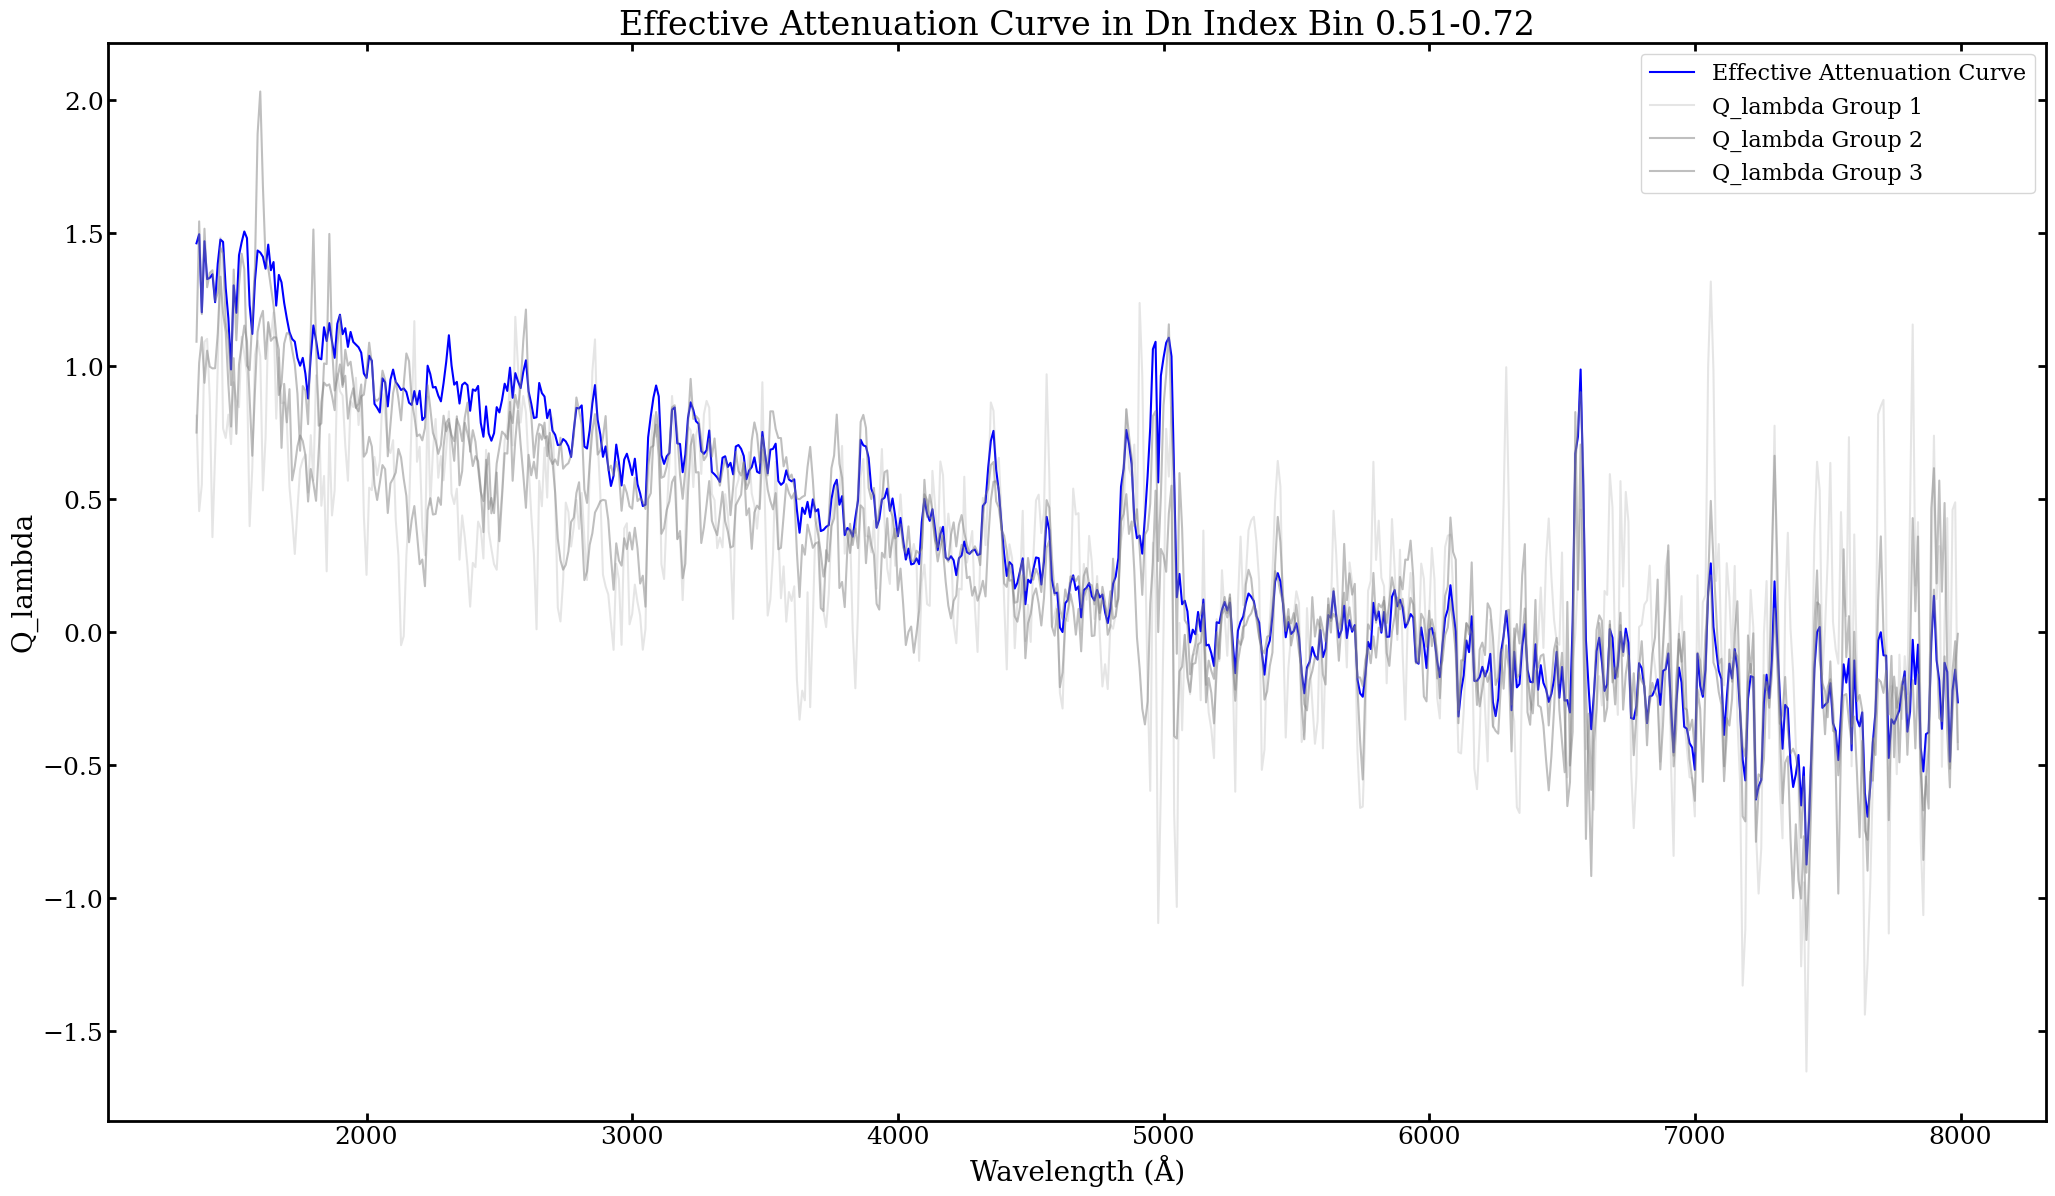

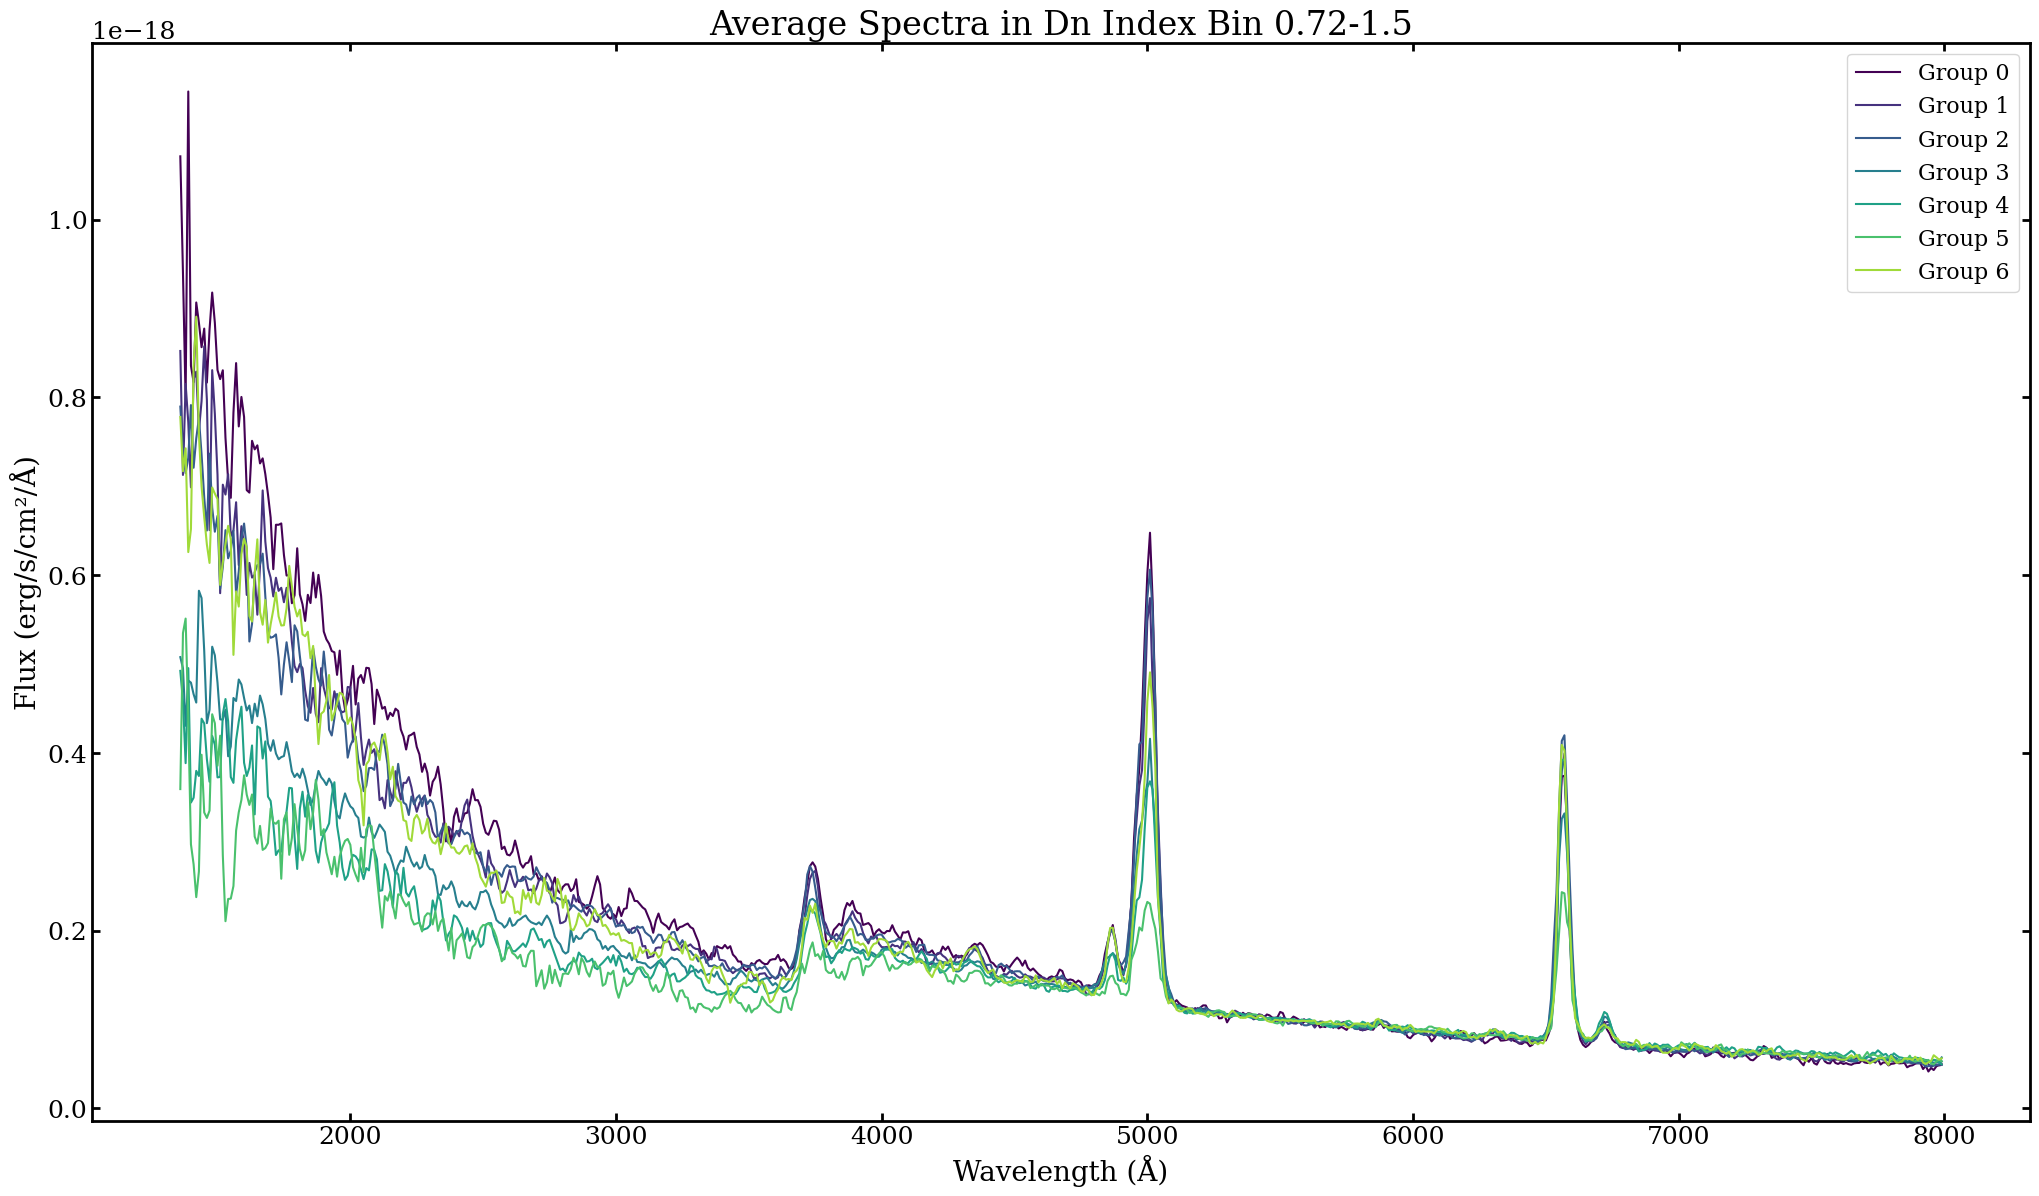

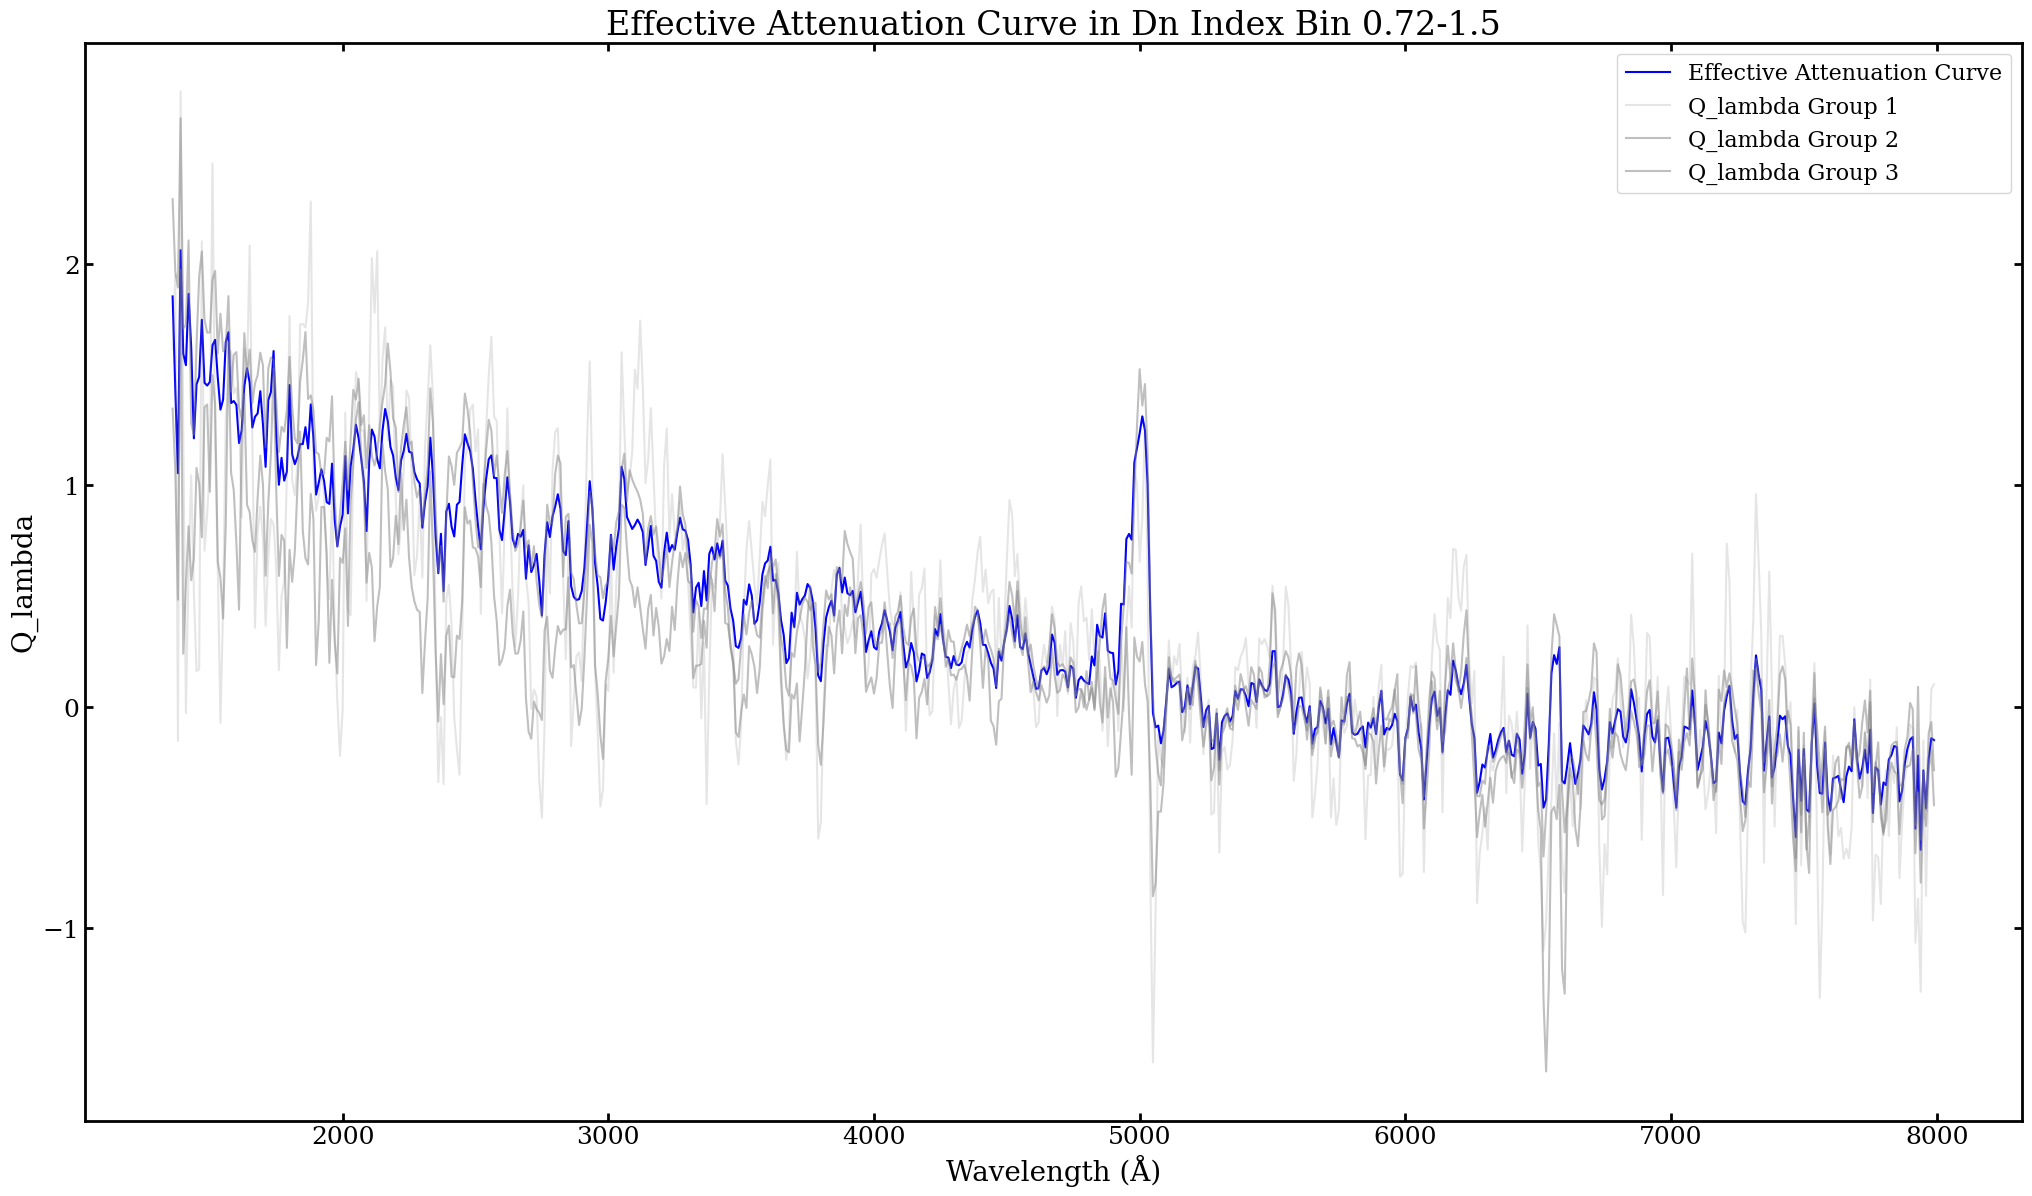

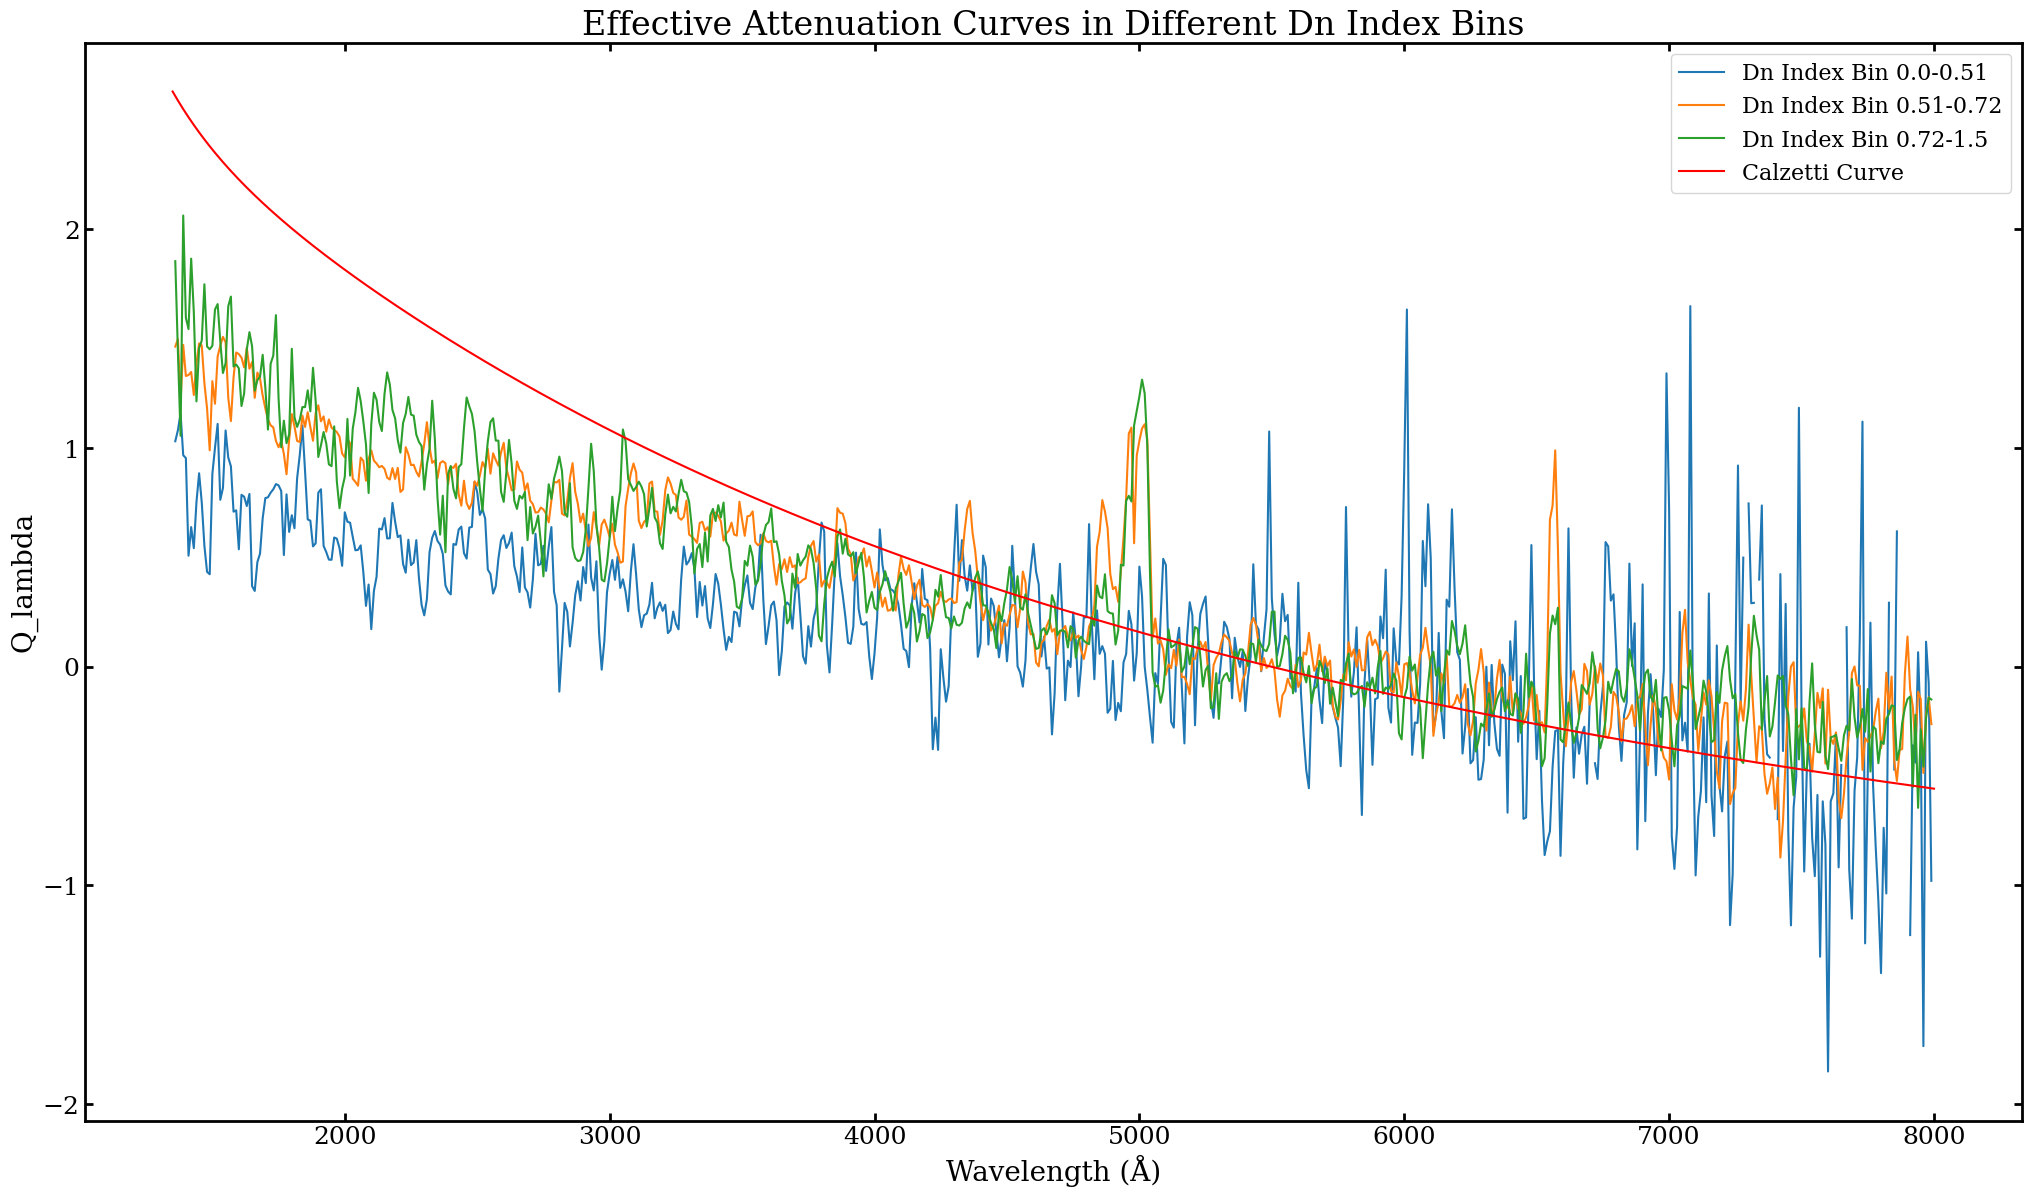

In [2]:
effective_attenuation_curve_list=[]

for dn_bin_index in range(len(dn_index_conditions)):

    group0_averager=FL.SpectrumAverager()
    group1_averager=FL.SpectrumAverager()
    group2_averager=FL.SpectrumAverager()
    group3_averager=FL.SpectrumAverager()
    group4_averager=FL.SpectrumAverager()
    group5_averager=FL.SpectrumAverager()
    group6_averager=FL.SpectrumAverager()


    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue

        dn_index=catalog['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['red_flux_density']/catalog['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['blue_flux_density']

        dn_bin_id=dn_condition_func(dn_index)
        if dn_bin_id != dn_bin_index:
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement)
        if group_index==-1:
            continue

        averager_to_use='group'+str(group_index)+'_averager'
        globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)
    invalid_averager=np.zeros(7, dtype=bool)
    for i in range(7):
        try:
            averager_to_use='group'+str(i)+'_averager'
            globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
            globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
            globals()[averager_to_use].spectrum_normalization_within_range(wavelength_range=(5250,5750),target_flux=1e-19)
            globals()[averager_to_use].compute_average_spectrum(method='median', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
            # globals()[averager_to_use].plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0)
            invalid_averager[i]=False

        except Exception as e:
            print(f'Warning: Unable to compute average spectrum for Redshift Bin {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}, Group {i}. Skipping this group.')
            invalid_averager[i]=True

    group_decrement_list=[]

    for i in range(6):
        decrement_list=[]

        for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
            if not catalog['sample_flag']:
                continue

            uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
            halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
            hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
            balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
            group_index=group_condition_func(balmer_decrement)
            if group_index!=i:
                continue
            if group_index==-1:
                continue

            decrement_list.append(balmer_decrement)

        group_decrement_list.append(np.mean(decrement_list))

    model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
    tau_lambda_list=[]
    Q_lambda_list=[]

    for i in range(1,6):
        if invalid_averager[i]:
            Q_lambda_list.append(np.zeros_like(group0_averager.common_wavelength))
            continue
        averager_to_use='group'+str(i)+'_averager'
        tau_lambda_list=[]
        groupi_averager=globals()[averager_to_use]
        tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
        tau_lambda_list.append(tau_lambda)
        Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
        Q_lambda_list.append(Q_lambda)

    fig, ax=plt.subplots(figsize=(25,14))
    colors=plt.cm.viridis(np.linspace(0,7))
    for i in range(7):
        if invalid_averager[i]:
            continue
        averager_to_use='group'+str(i)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
    ax.set_xlabel('Wavelength (Å)', fontsize=20)
    ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=20)
    ax.set_title(f'Average Spectra in Dn Index Bin {dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', fontsize=24)
    ax.legend(fontsize=16)
    plt.show()


    Q_lambda_array=np.array(Q_lambda_list)

    valid_weights = []
    for i in range(1,6):
        if not invalid_averager[i]:
            valid_weights.append(group_decrement_list[i]-group_decrement_list[0])

    effective_attenuation_curve=np.average(Q_lambda_array[~np.array(invalid_averager[1:-1])], axis=0, weights=valid_weights)
    fig, ax=plt.subplots(figsize=(25,14))
    averager=group1_averager
    ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
    for i in range(0,3):
        if invalid_averager[i+1]:
            continue
        Q_lambda=Q_lambda_list[i]
        averager_to_use='group'+str(i+1)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))
    plt.xlabel('Wavelength (Å)', fontsize=20)
    plt.ylabel('Q_lambda', fontsize=20)
    plt.title('Effective Attenuation Curve in Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', fontsize=24)
    plt.legend(fontsize=16)
    plt.show()
    effective_attenuation_curve_list.append((averager.common_wavelength, effective_attenuation_curve))


colors=sns.color_palette( n_colors=len(dn_index_conditions))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
fig, ax=plt.subplots(figsize=(25,14))

for dn_bin_index in range(len(dn_index_conditions)):
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[dn_bin_index]
    ax.plot(common_wavelength, effective_attenuation_curve, label='Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', color=colors[dn_bin_index])

ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves in Different Dn Index Bins', fontsize=24)
plt.legend(fontsize=16)
plt.show()

Spectrum index 5 has invalid normalization factor. Skipping.


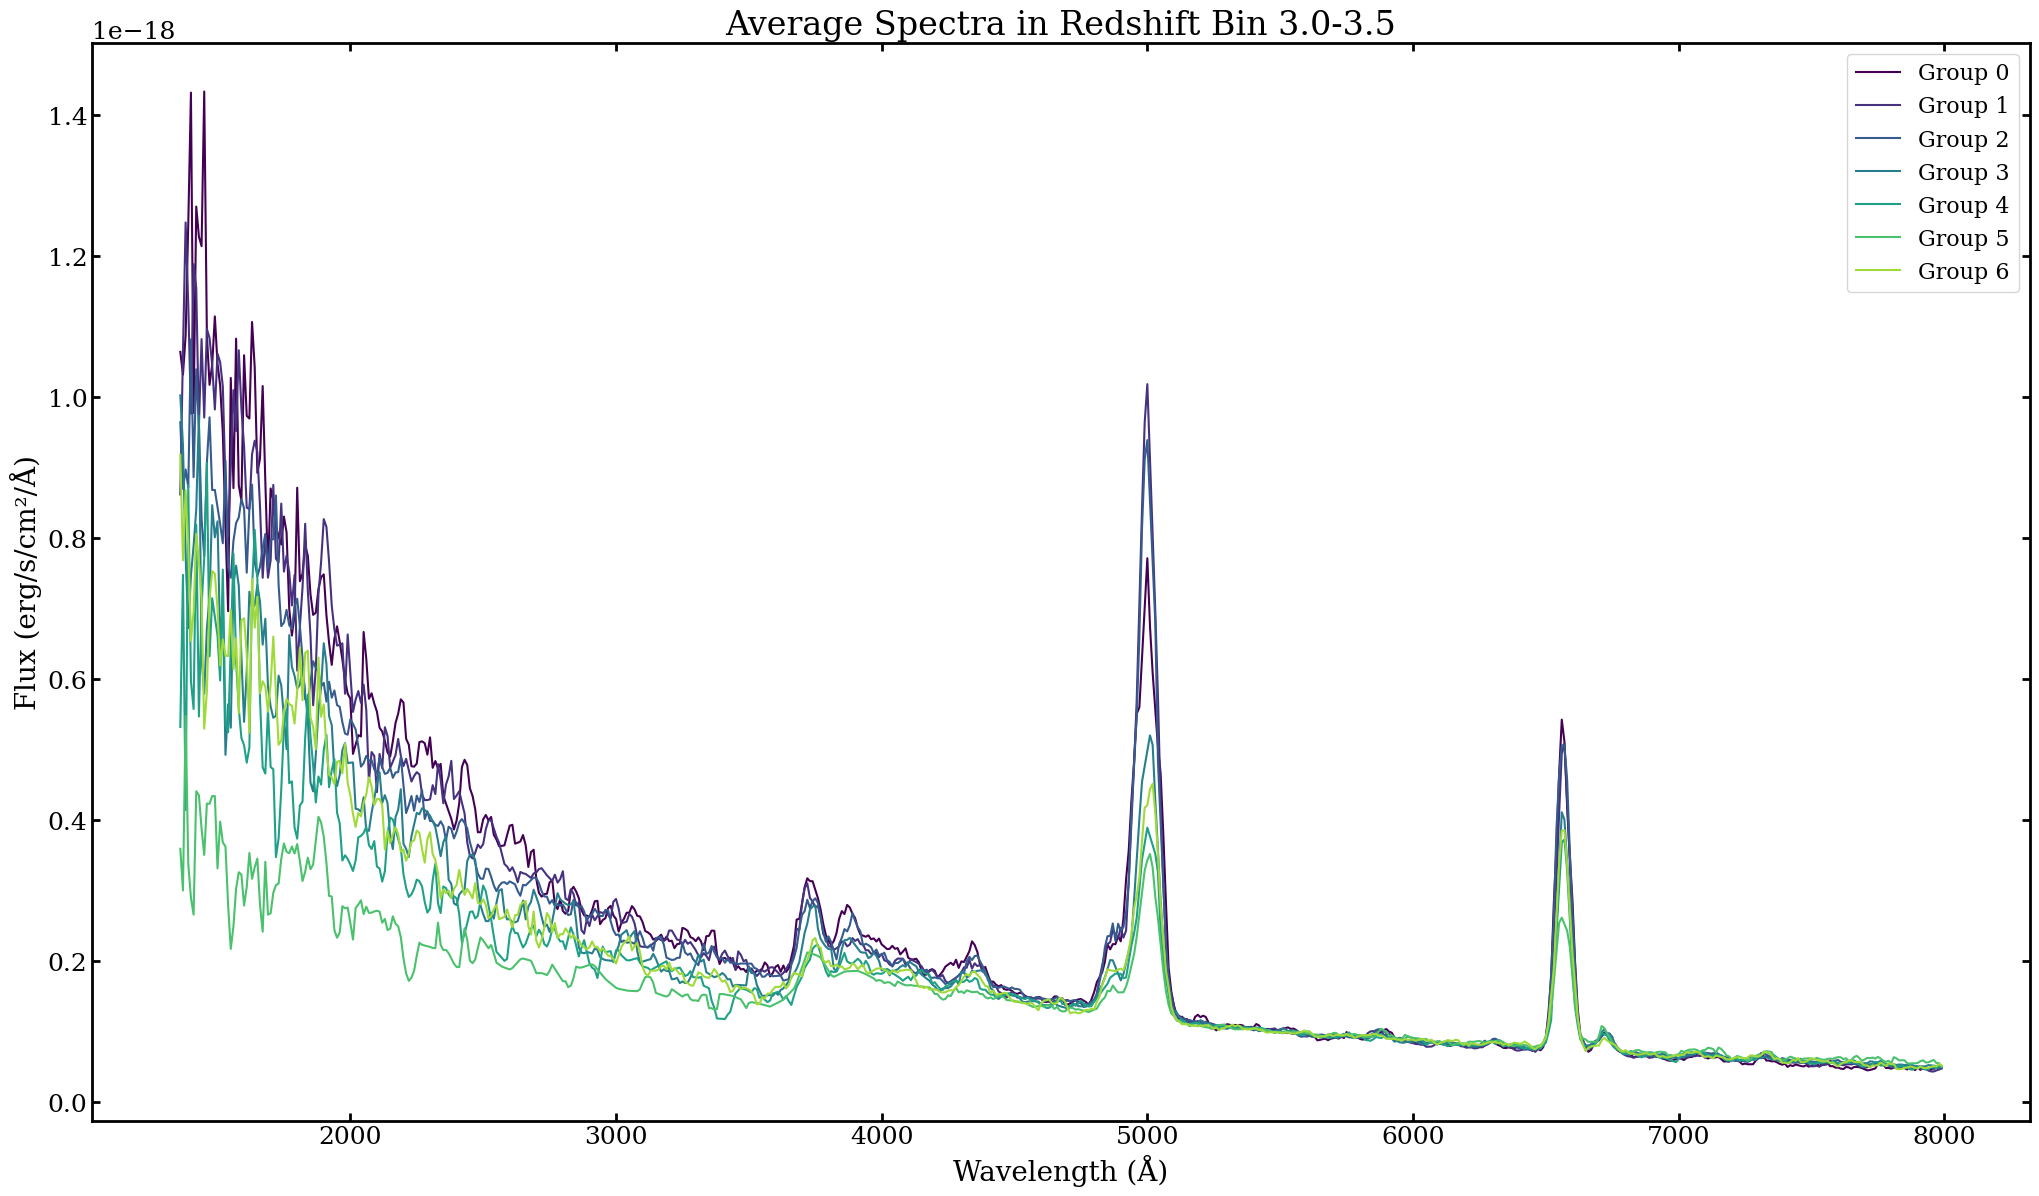

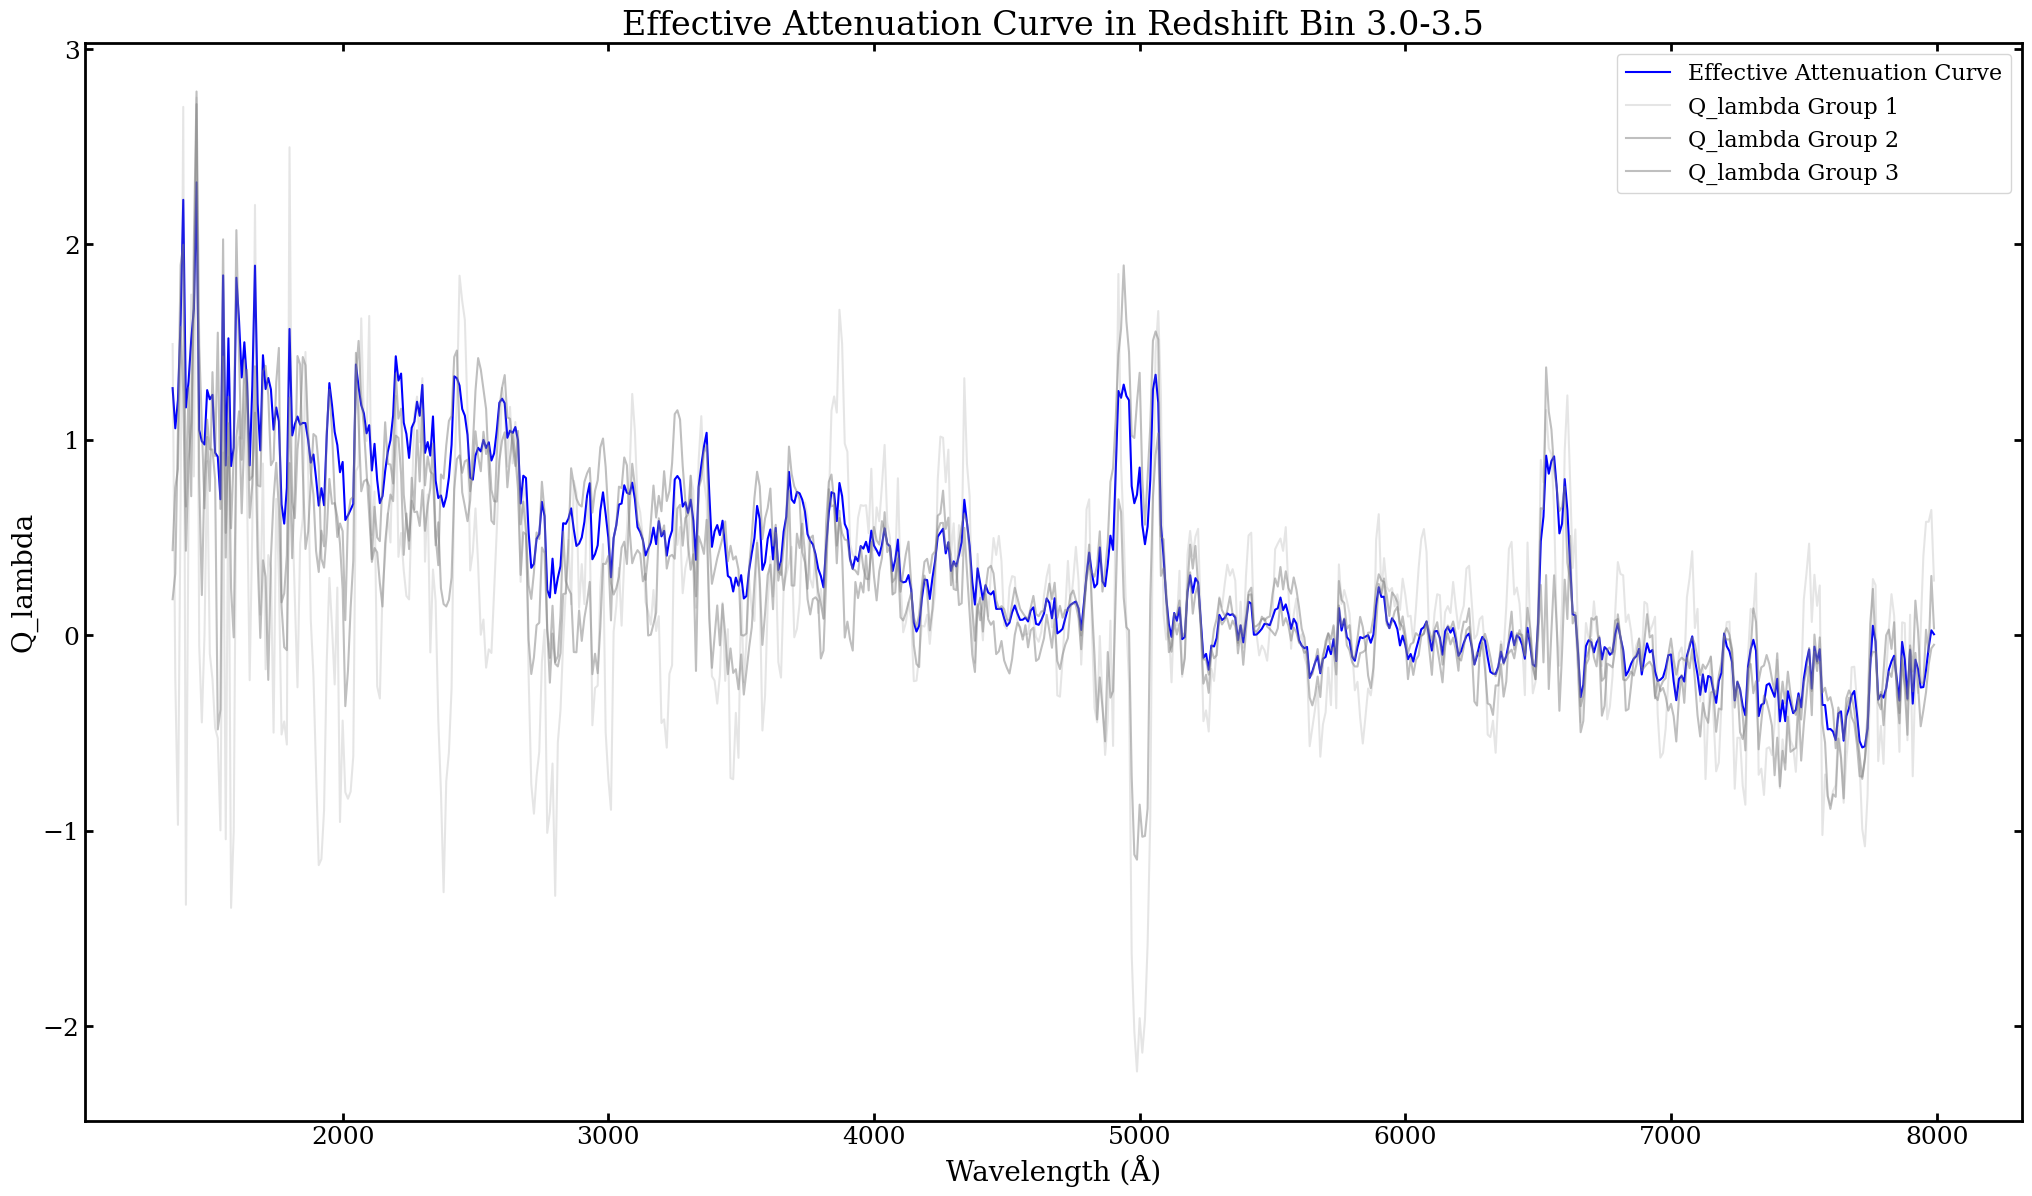

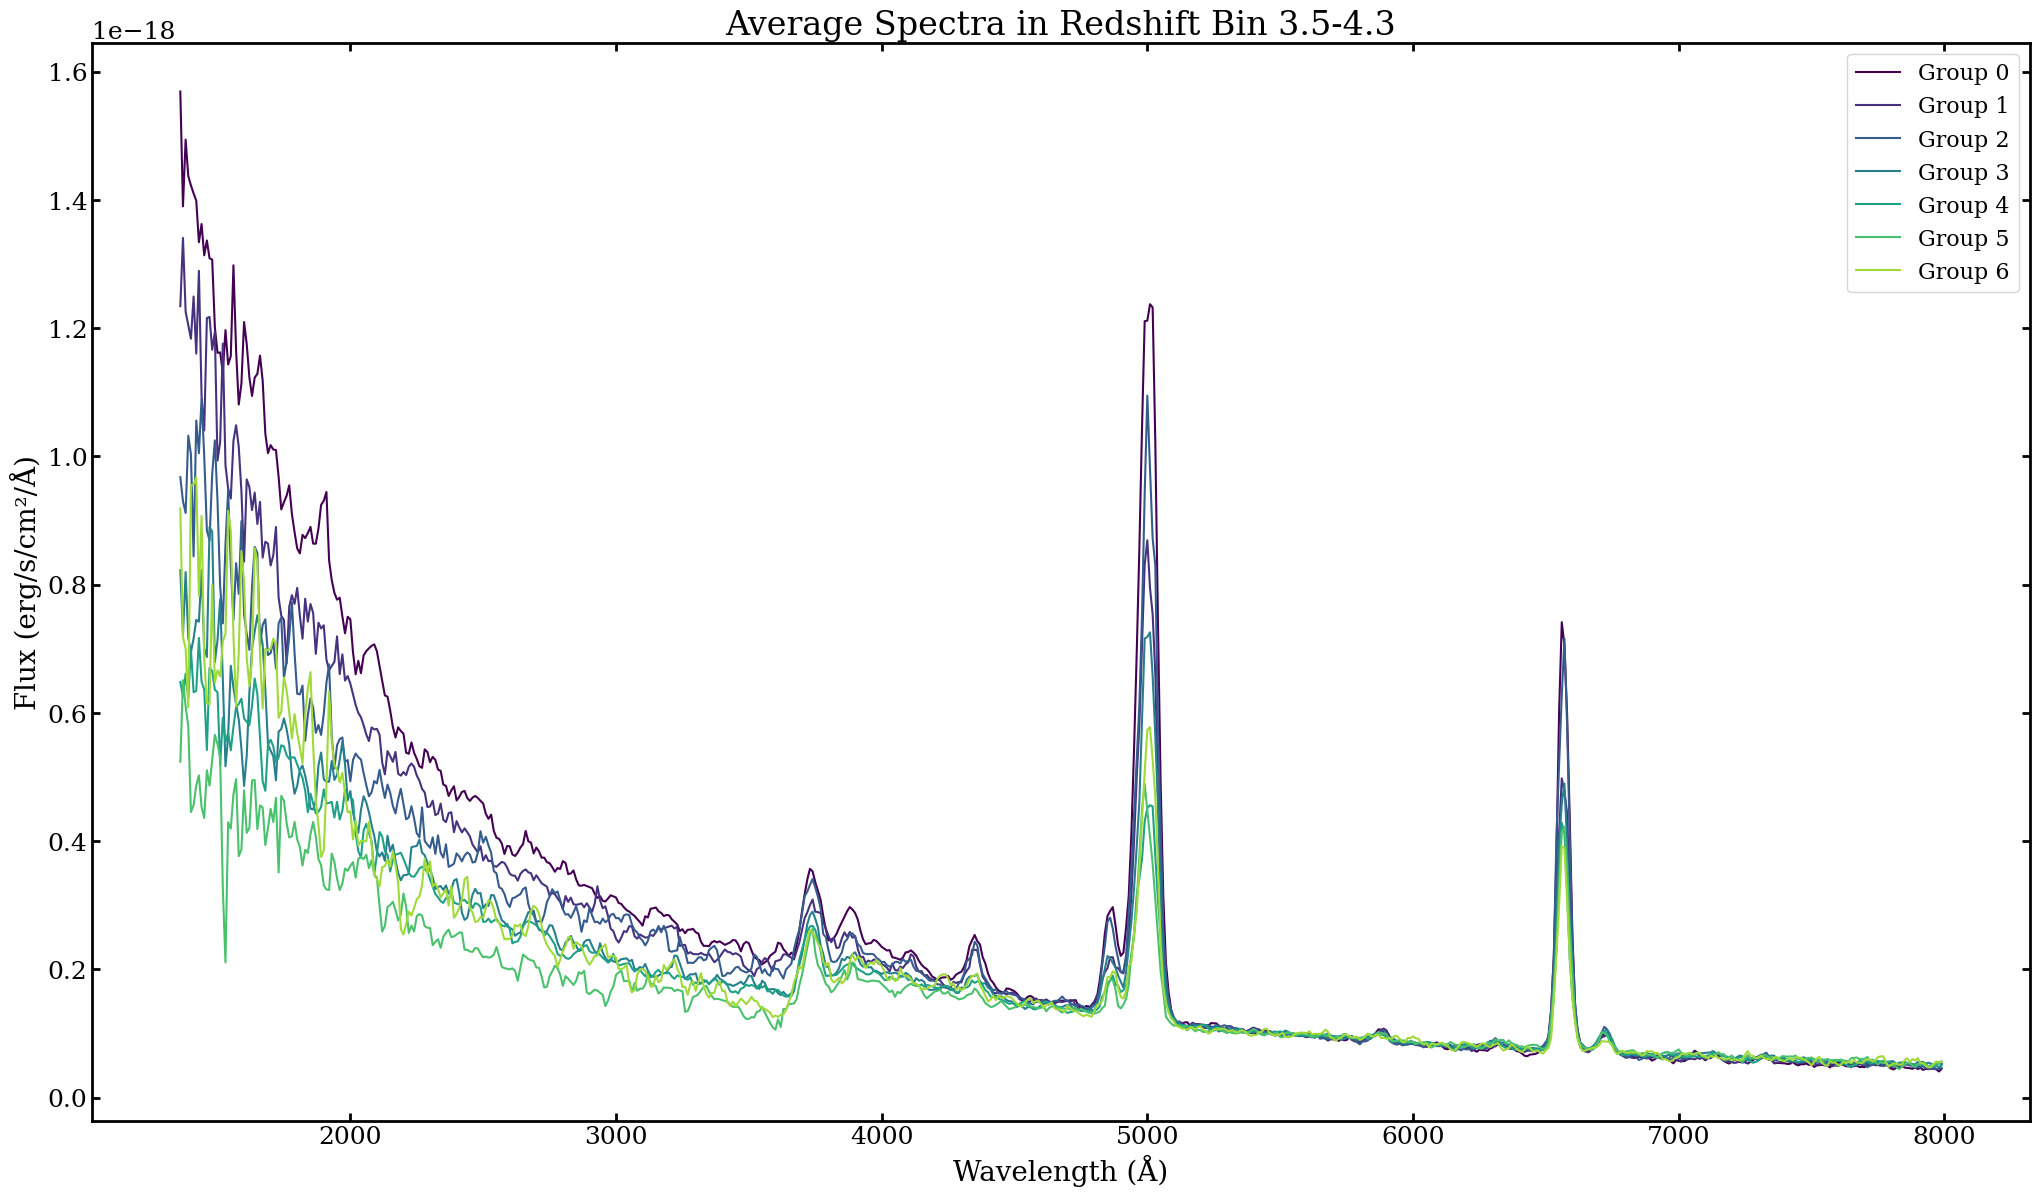

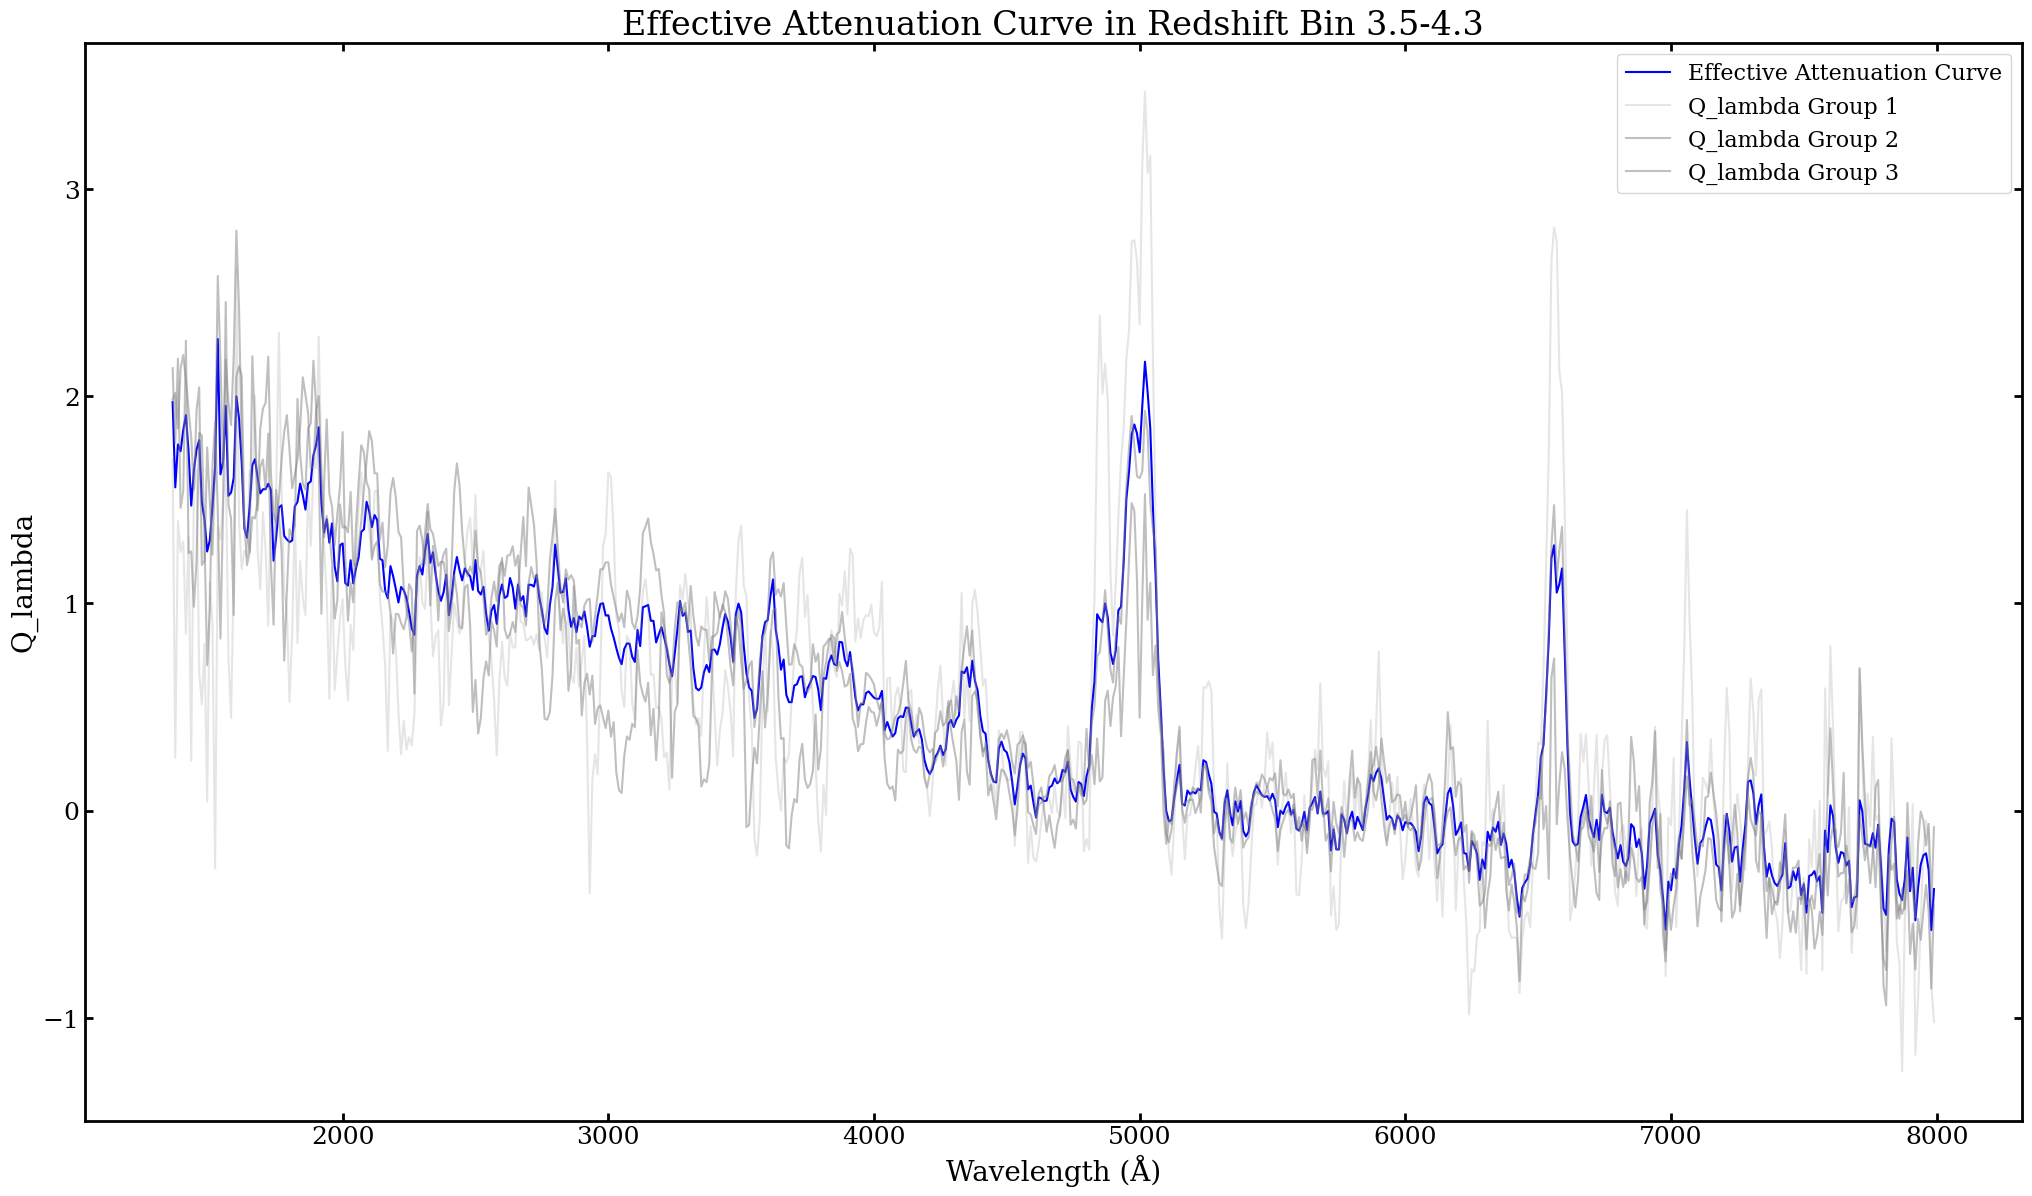

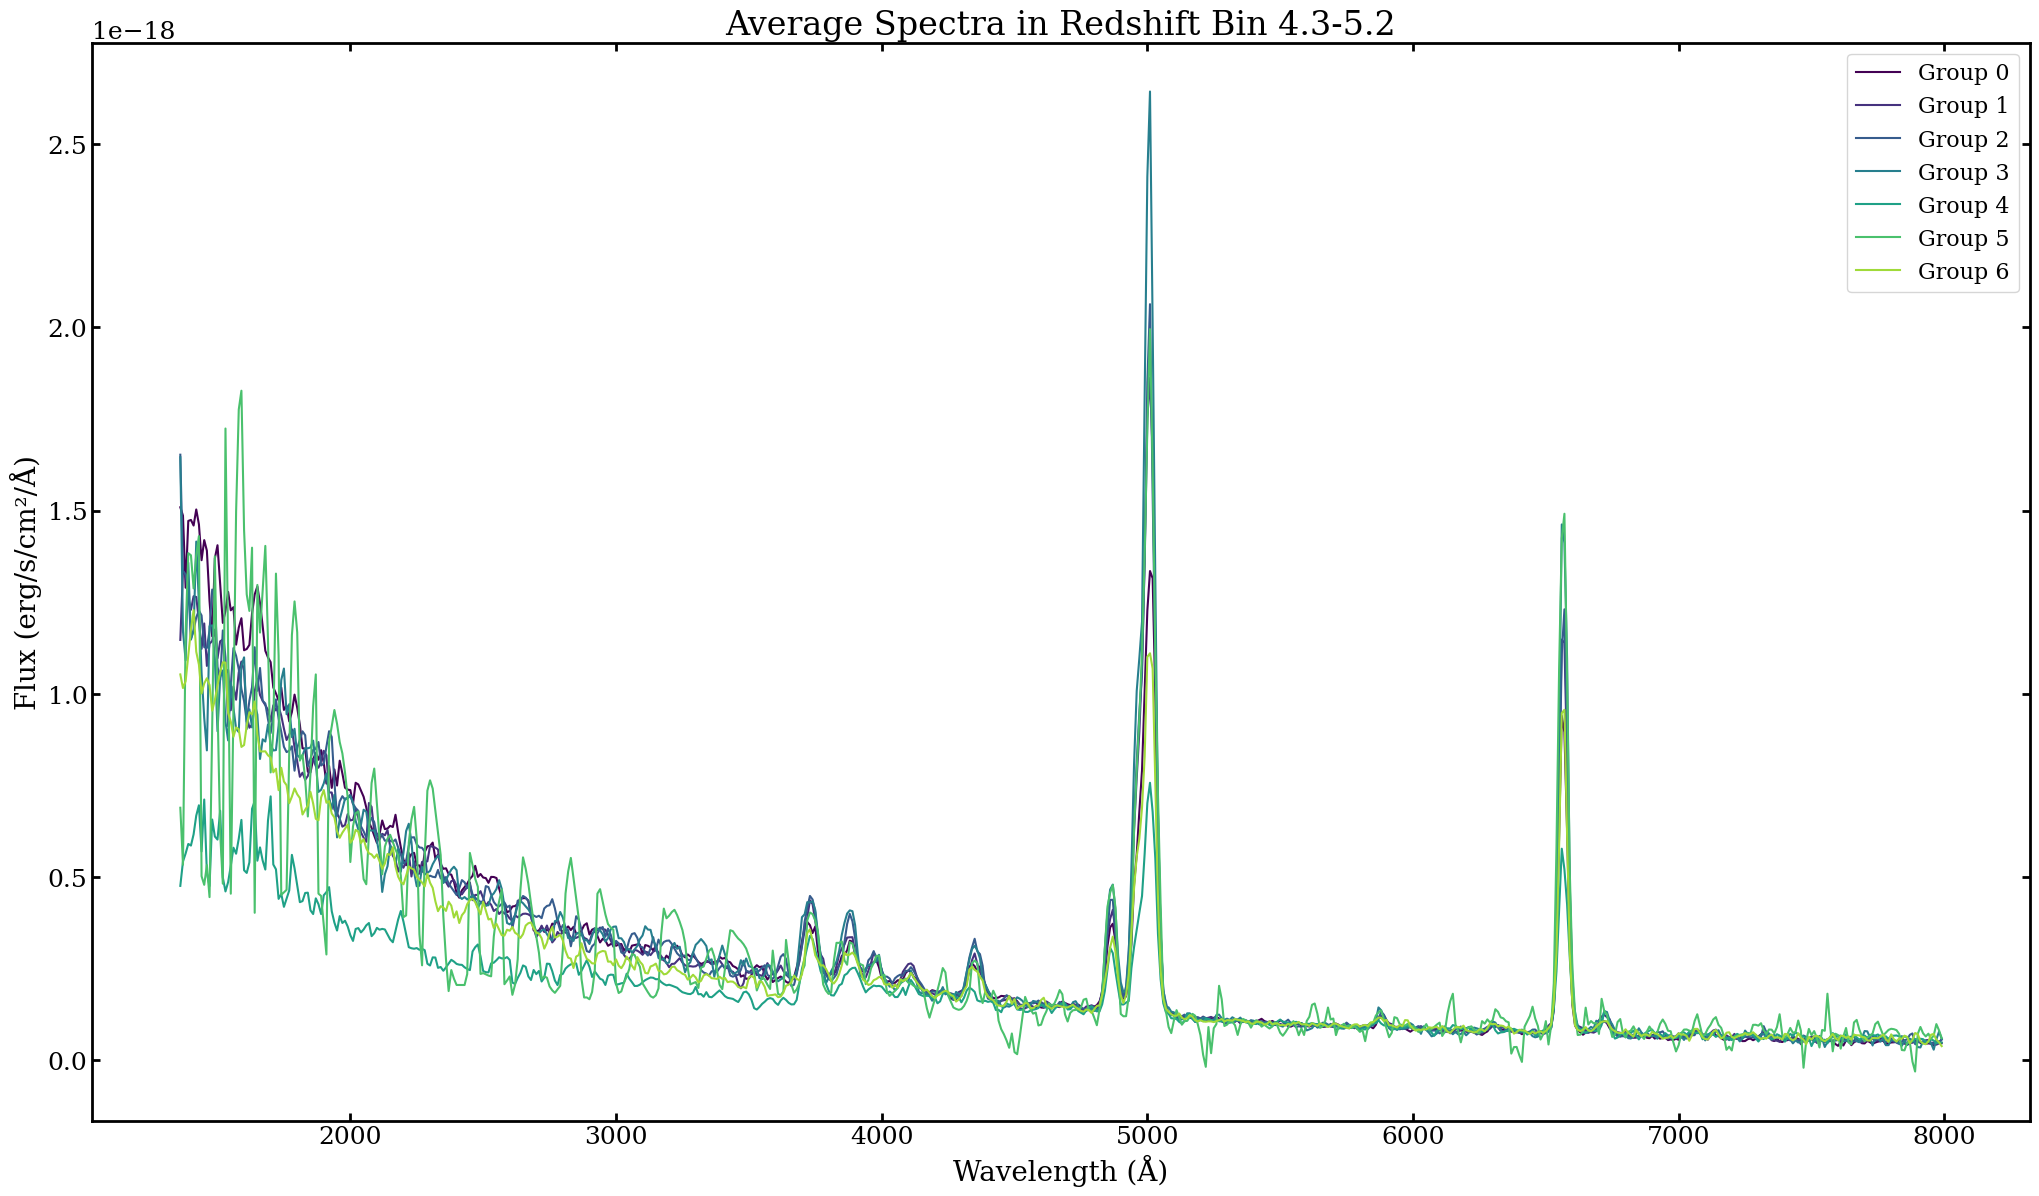

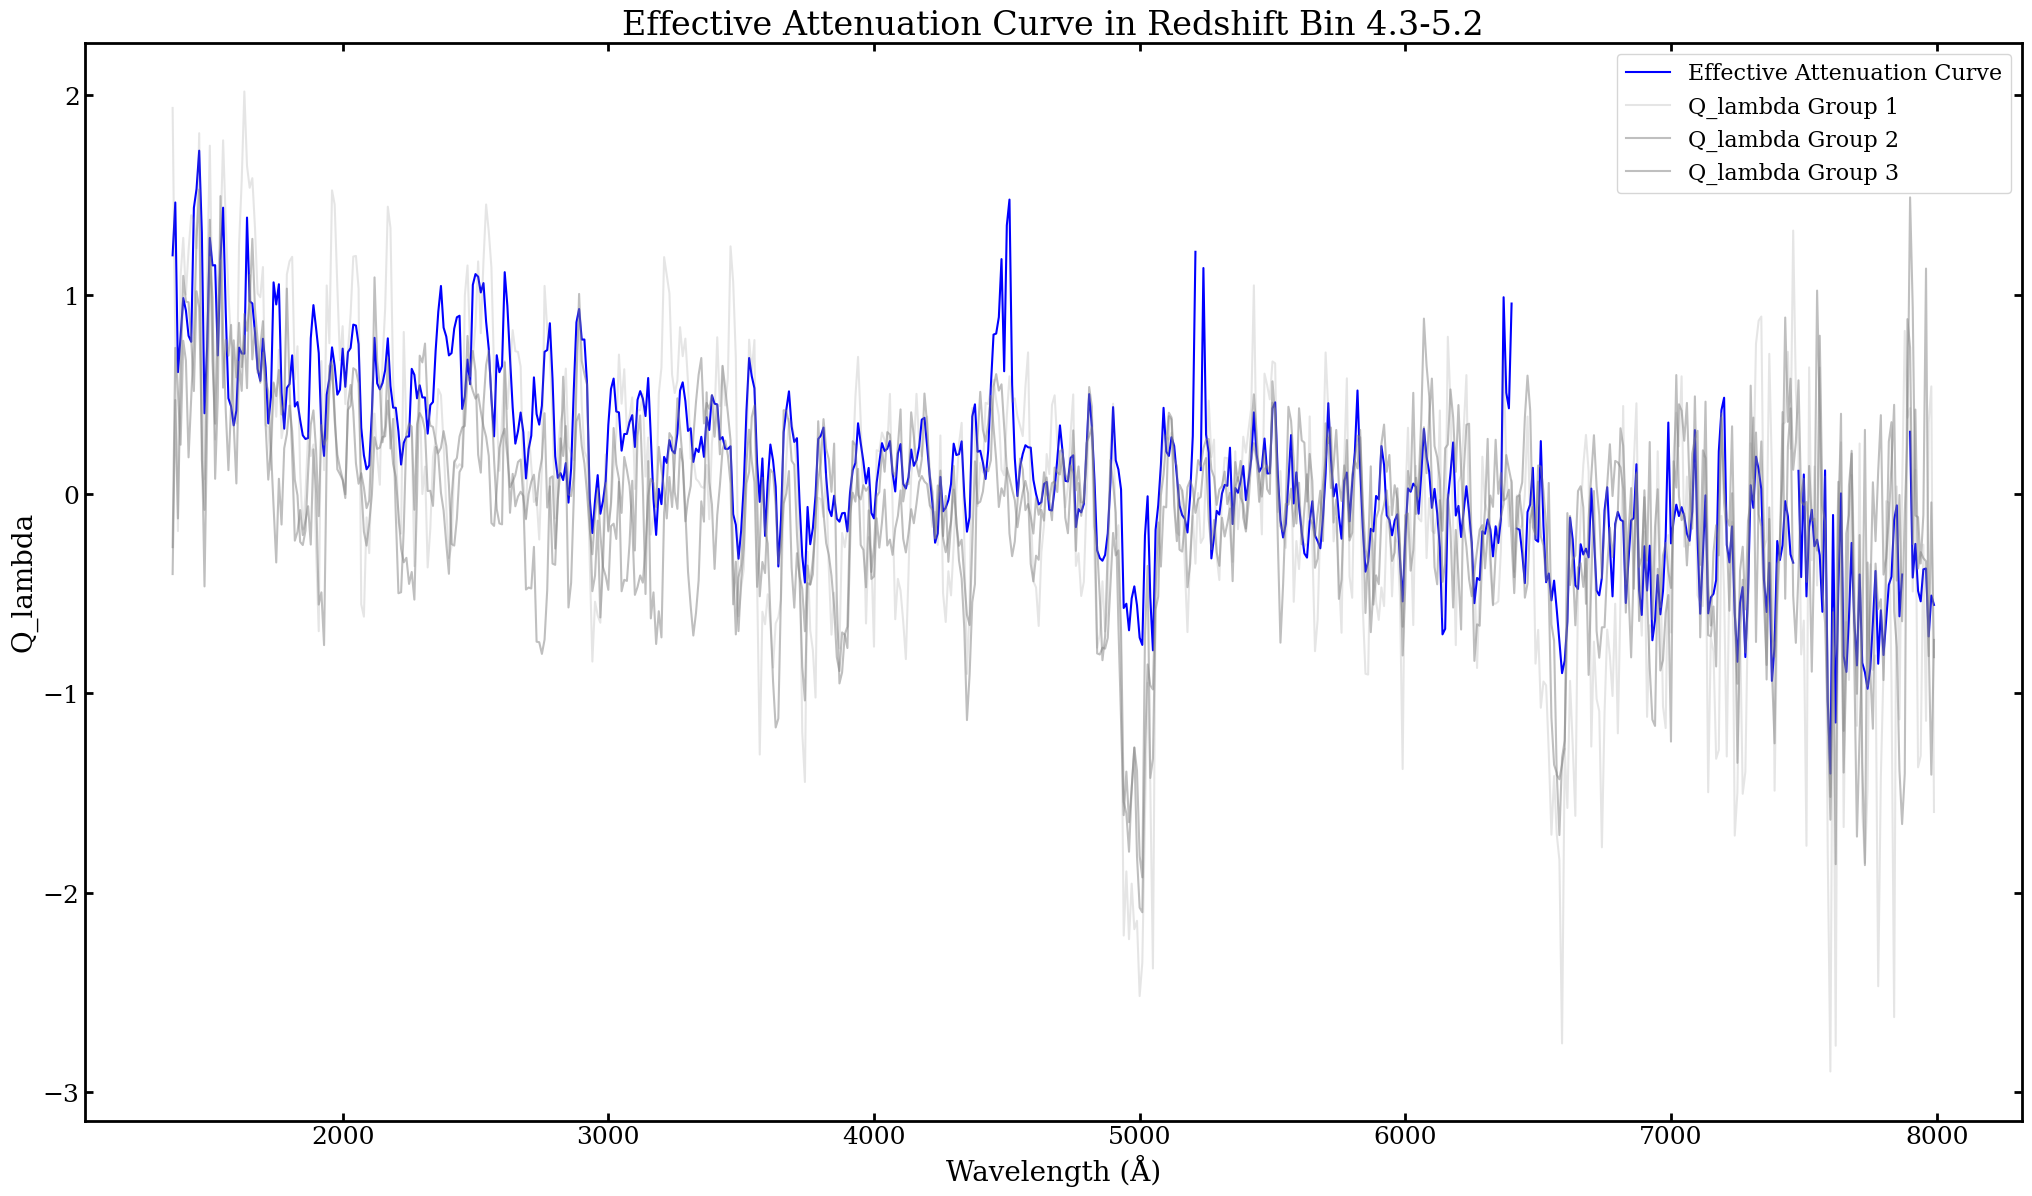

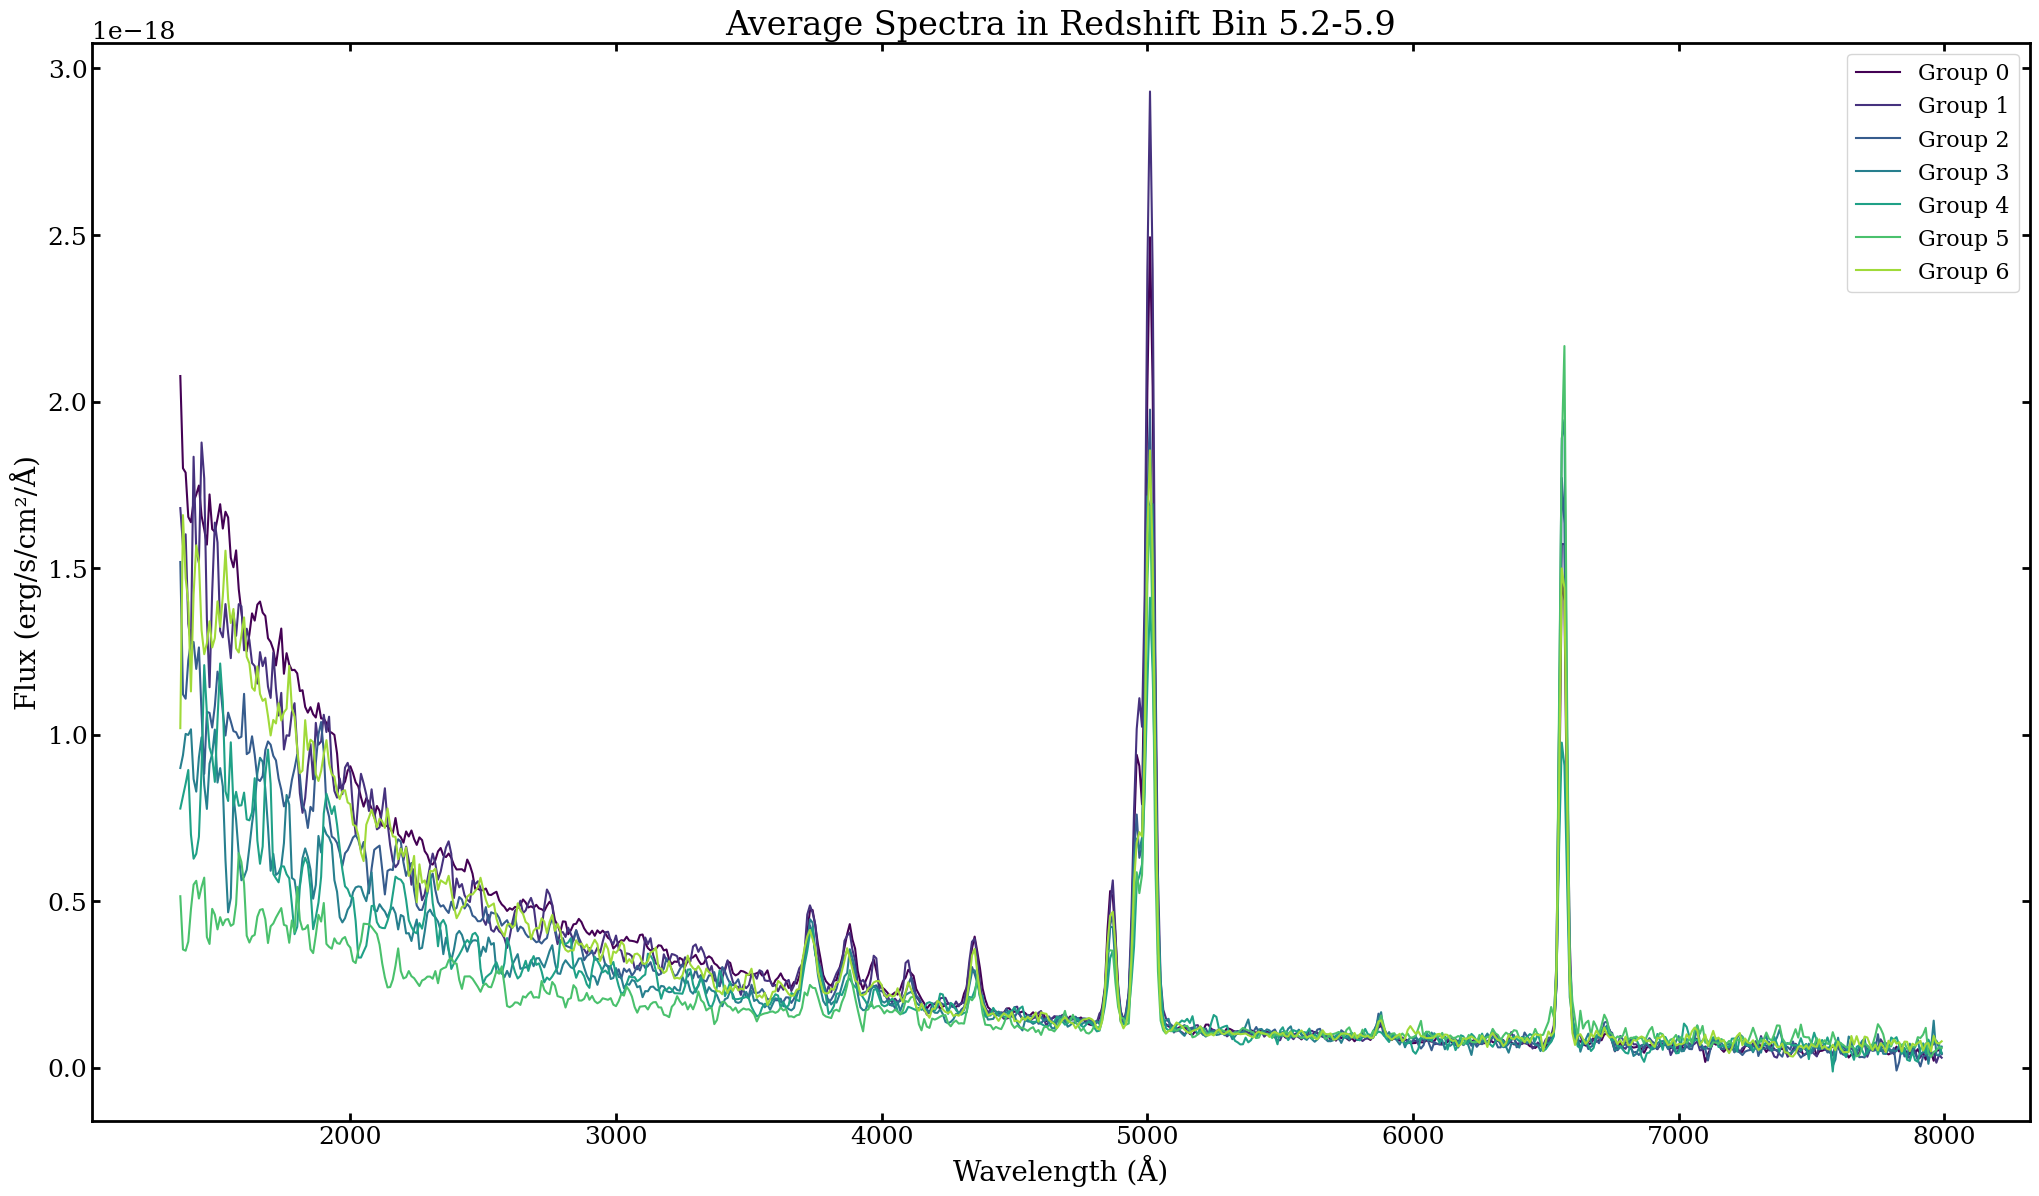

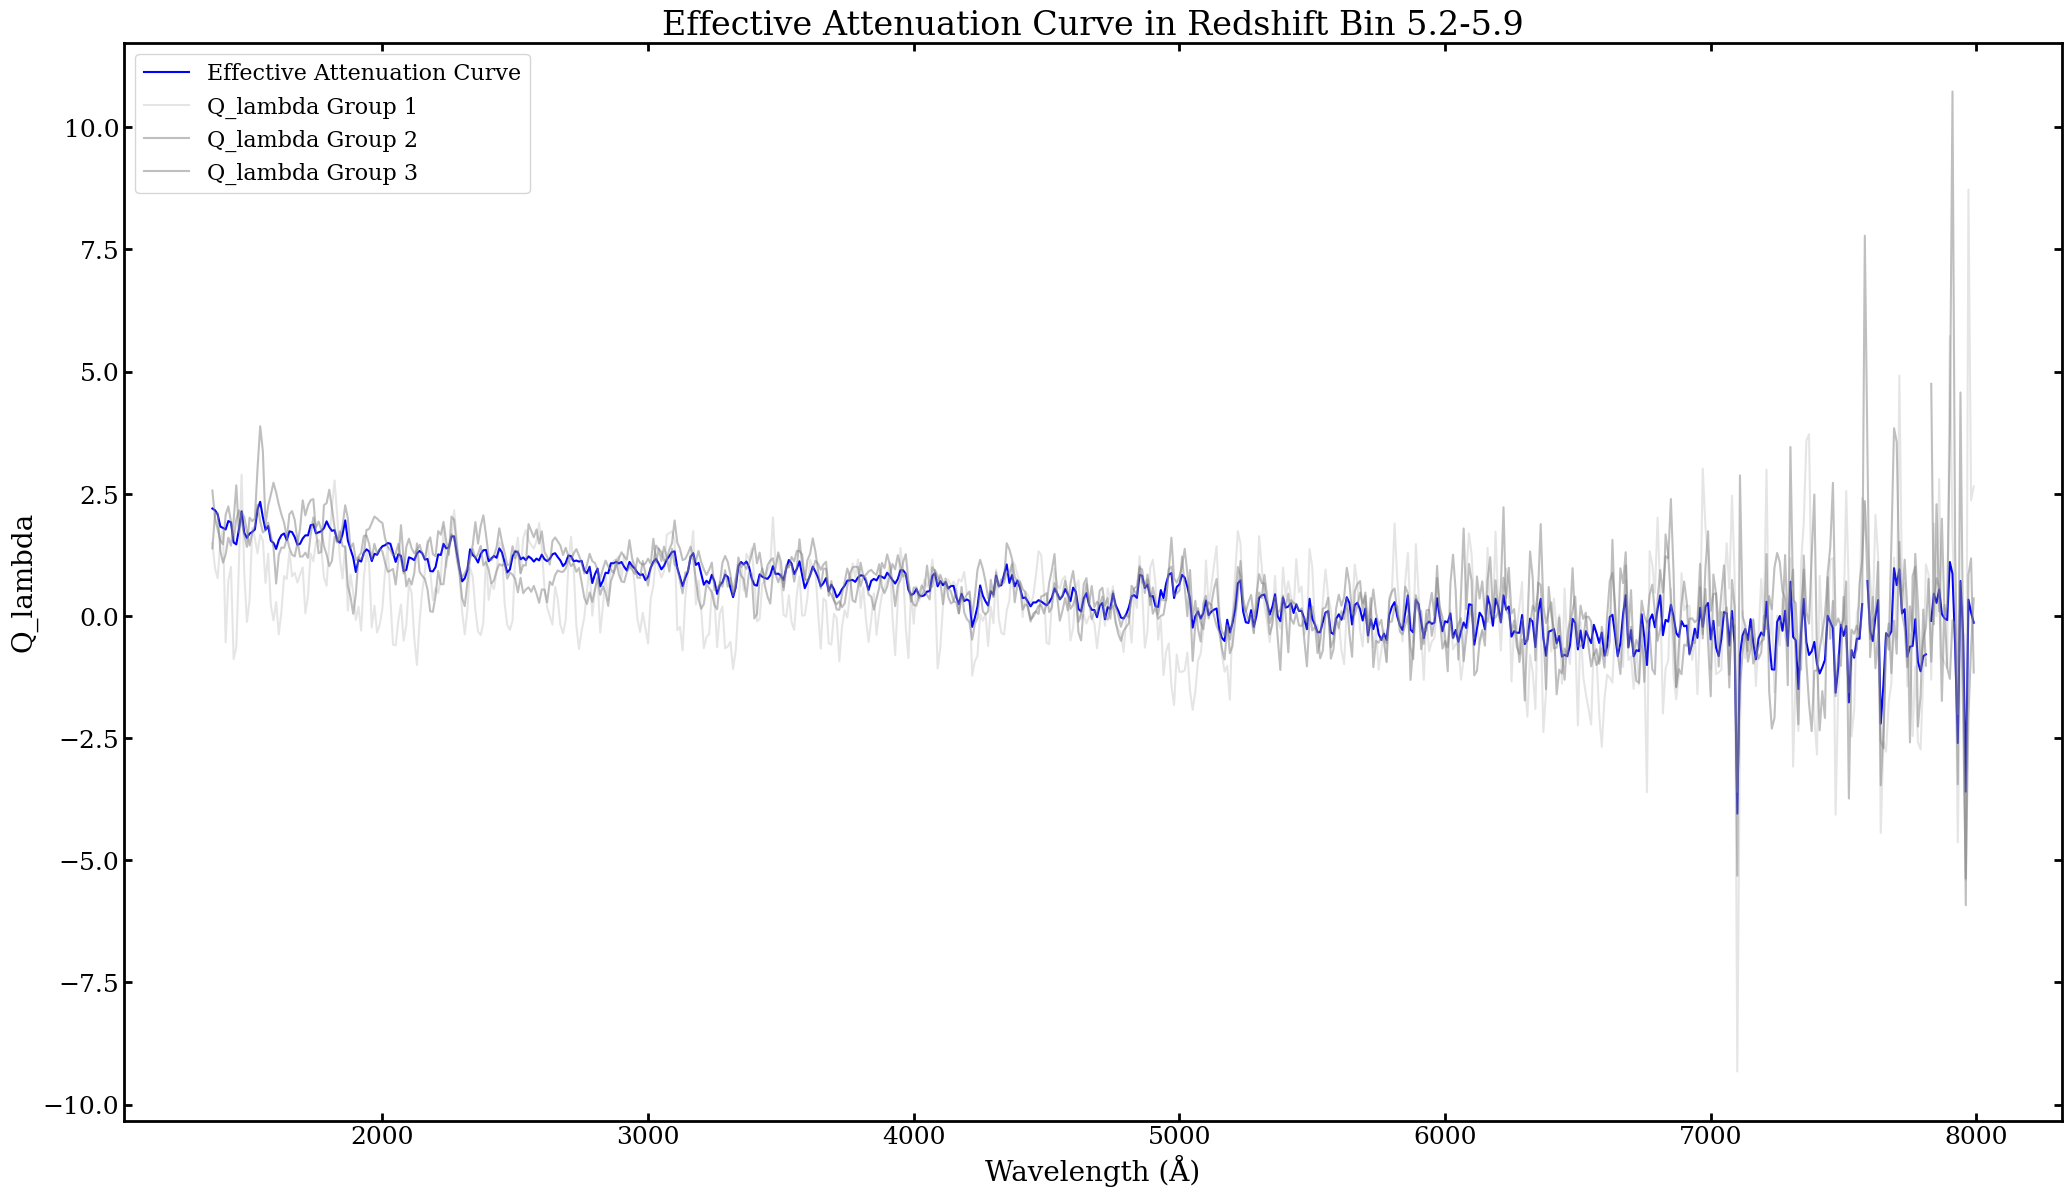

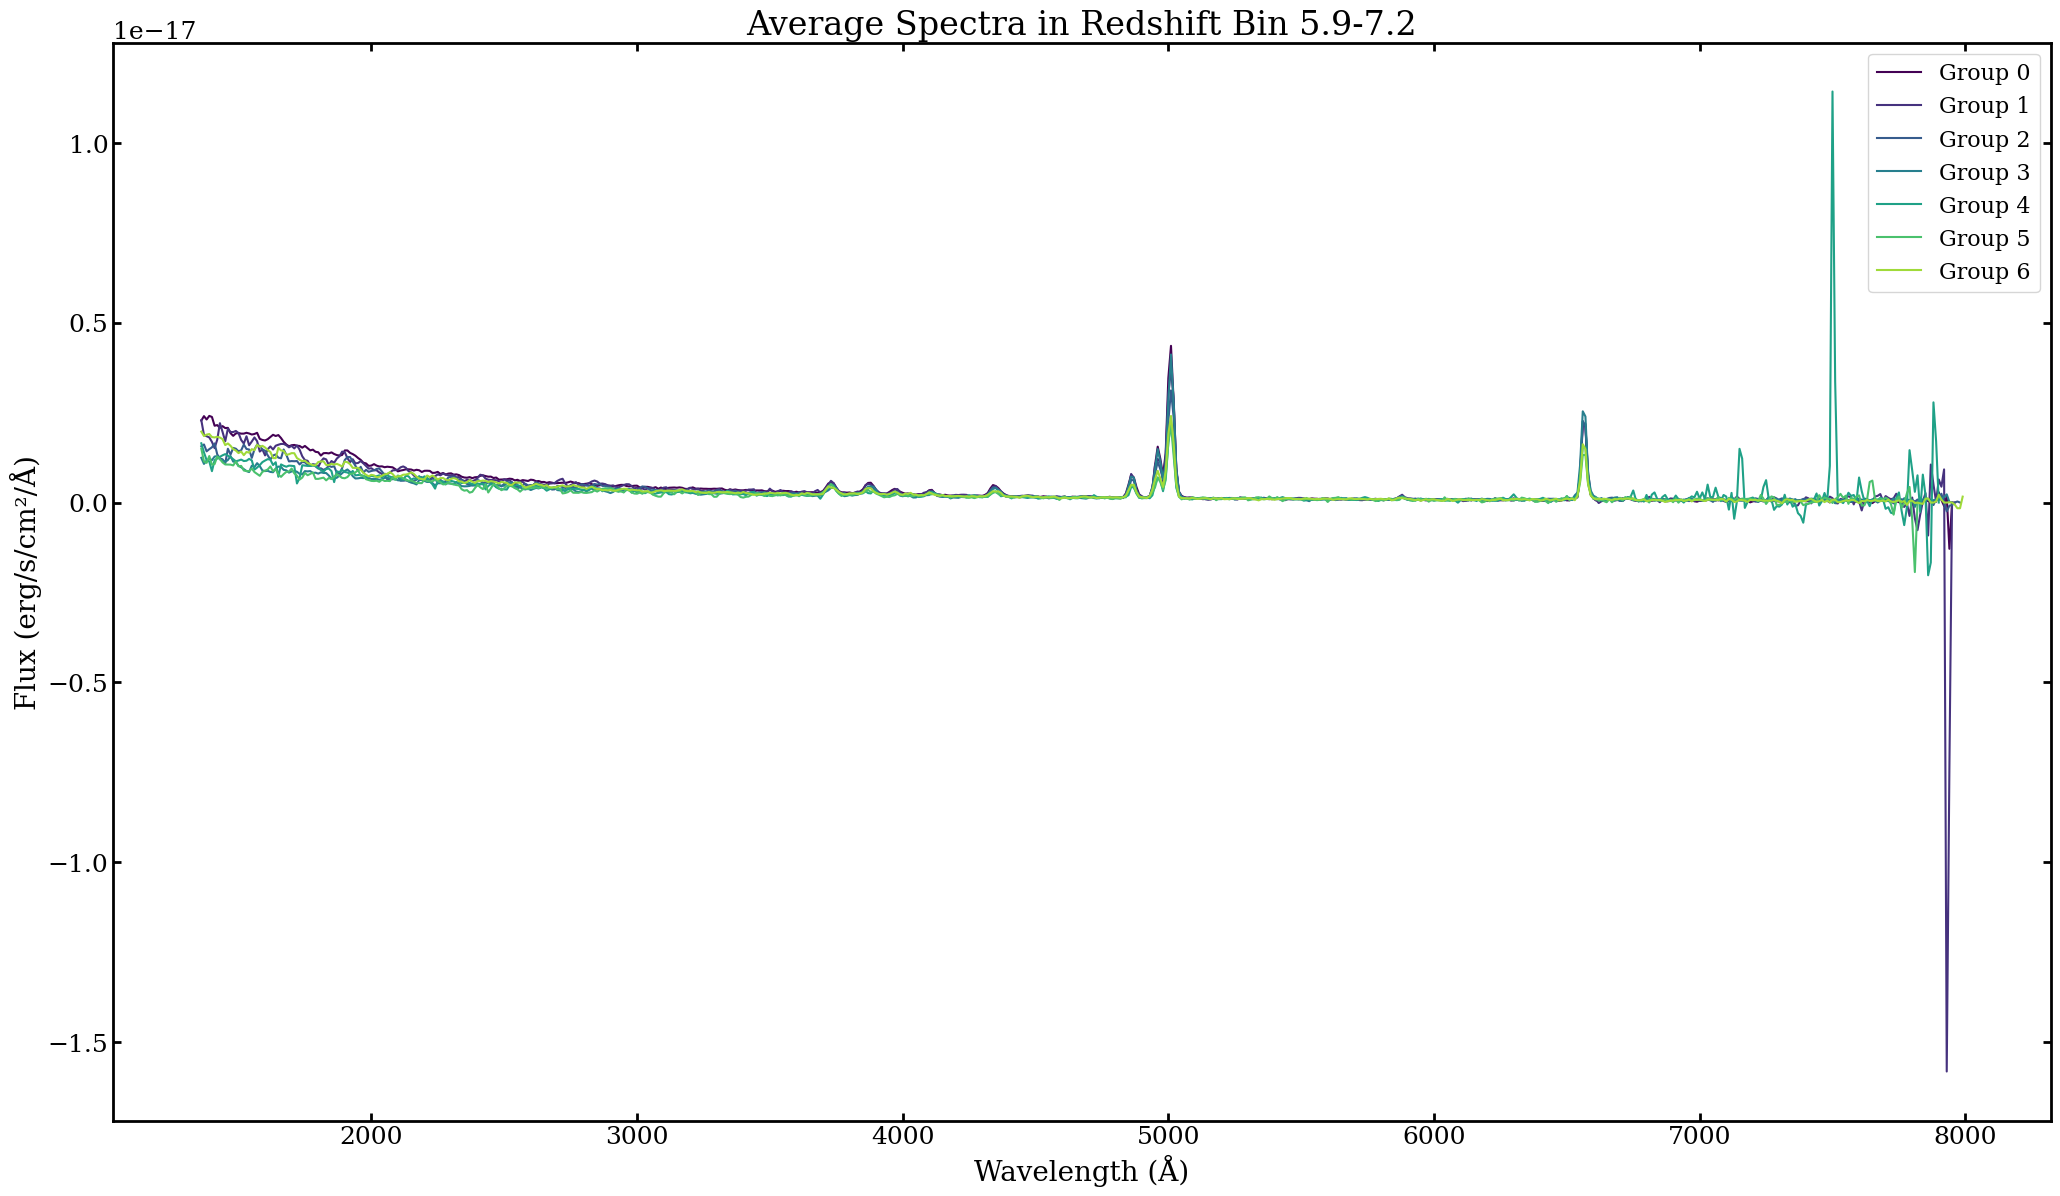

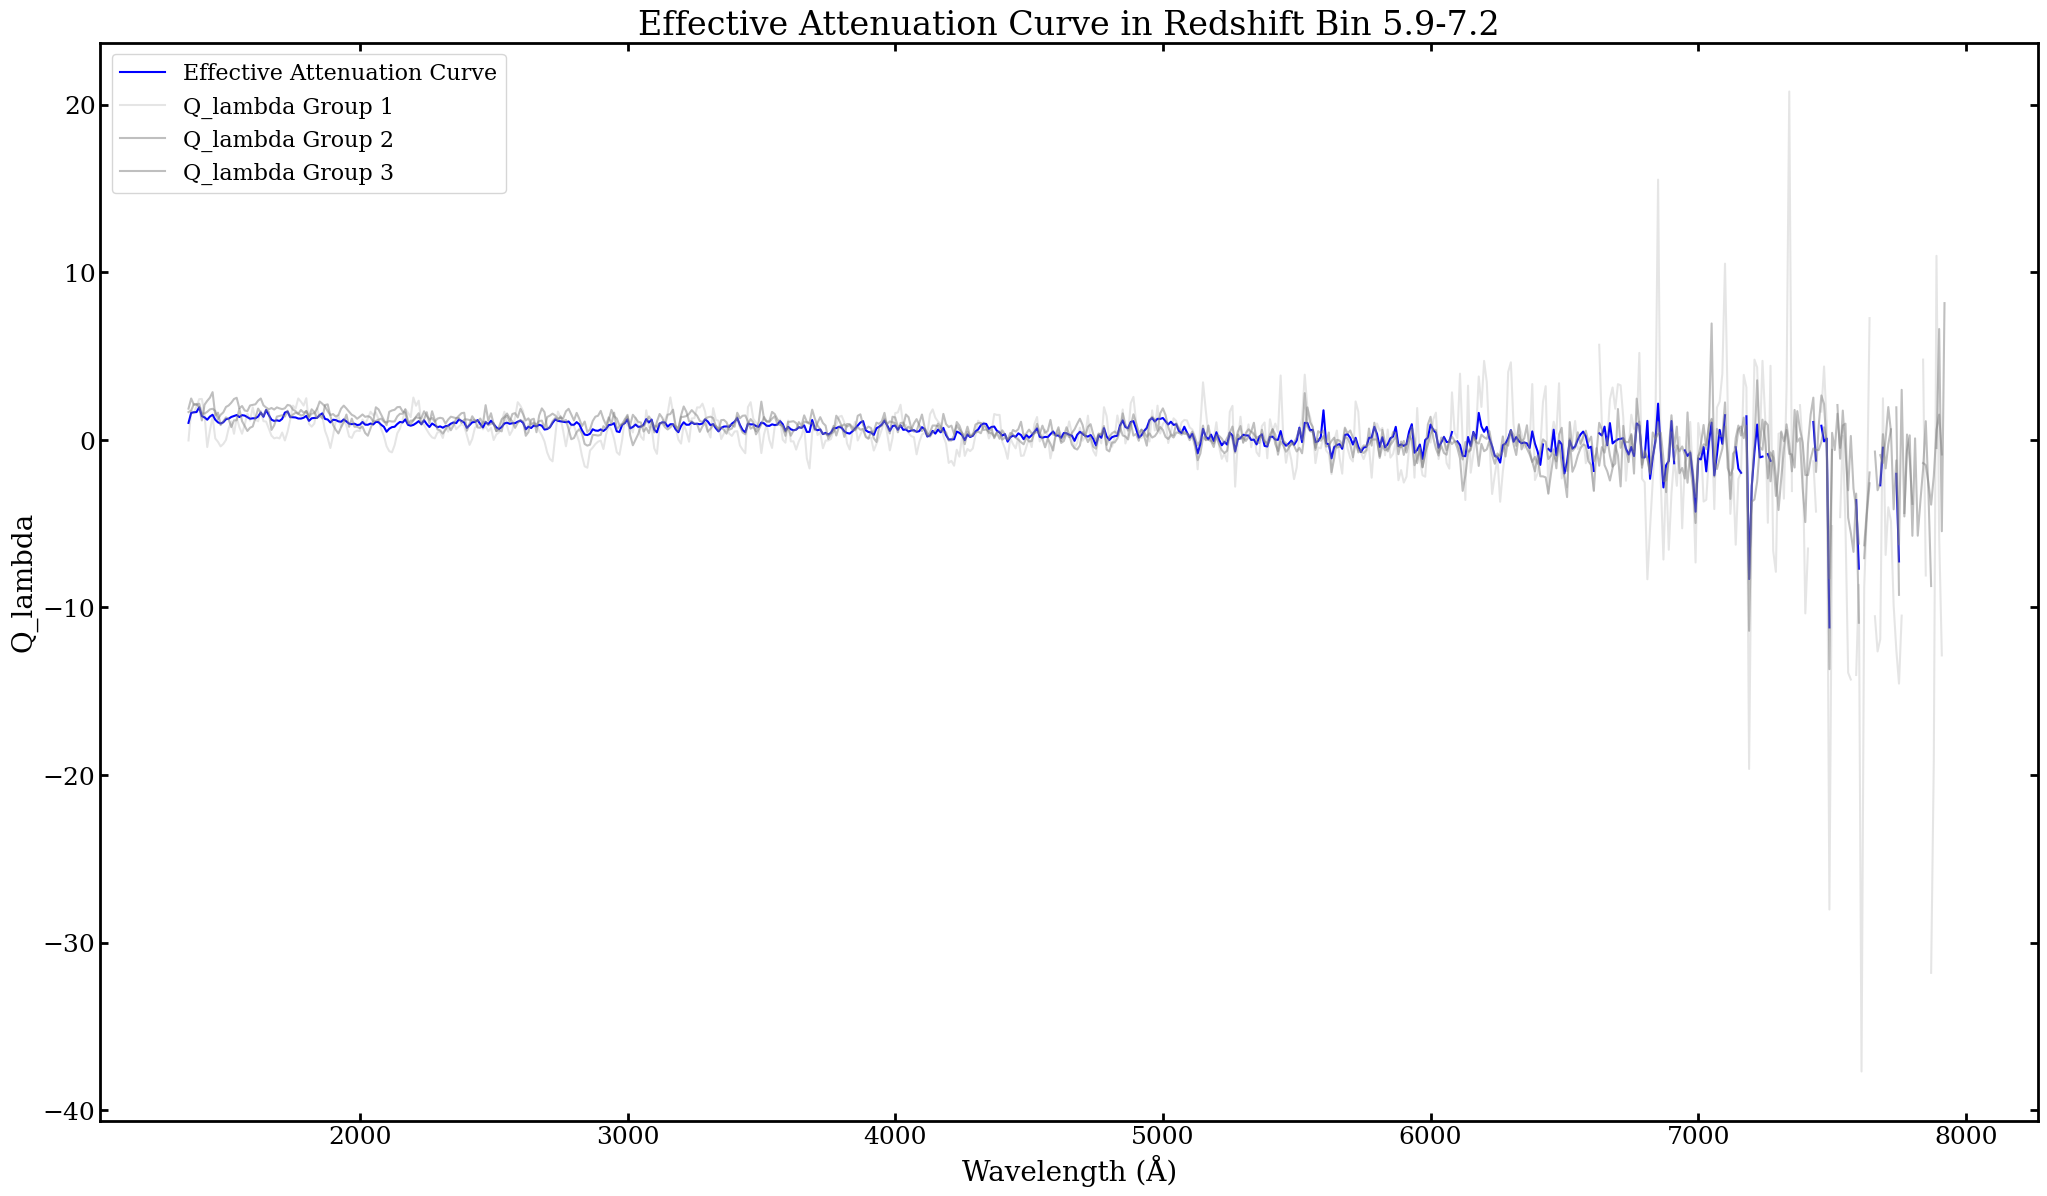

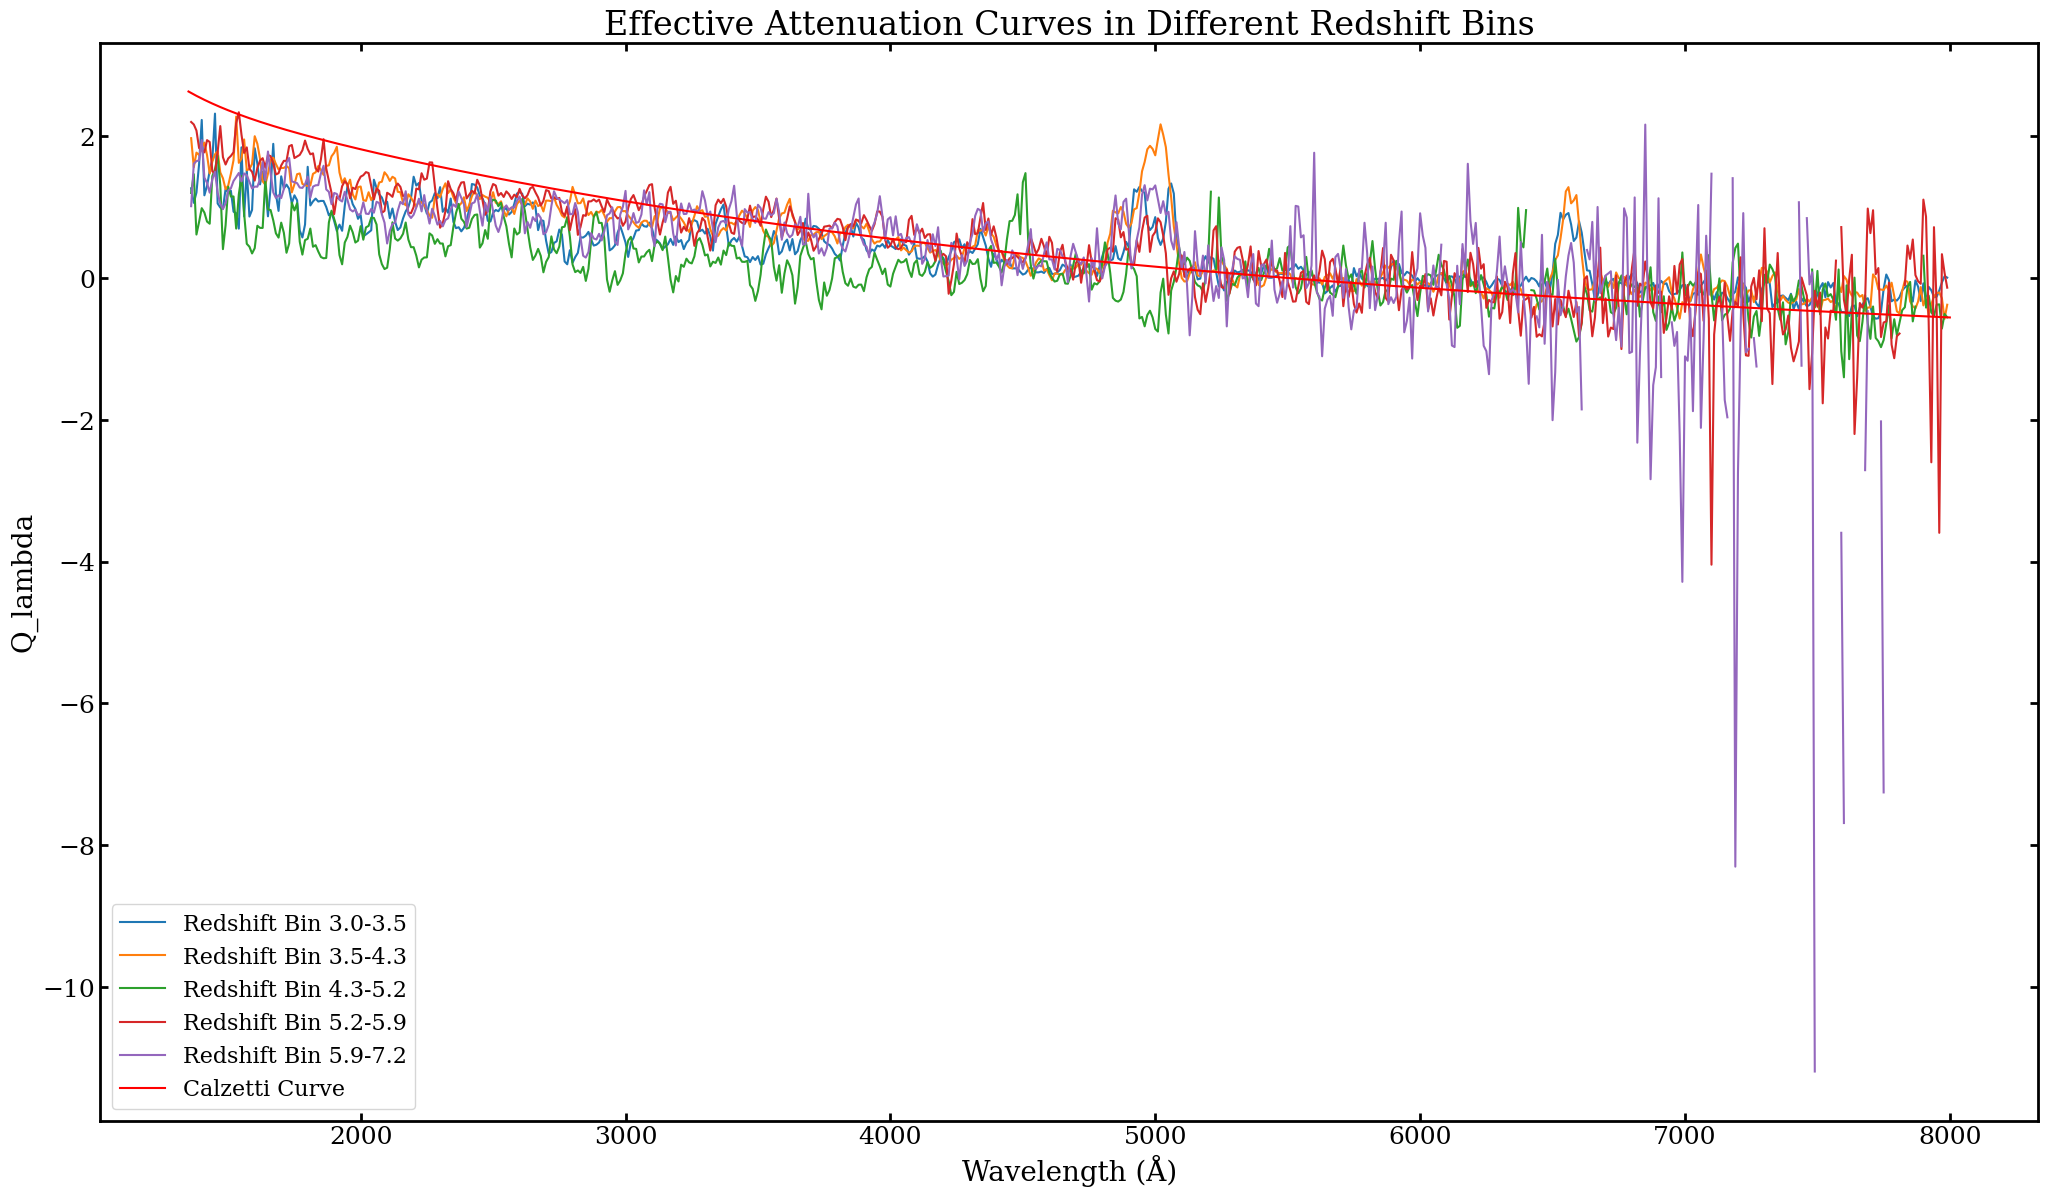

In [3]:
redshift_conditions=np.array([[3,3.5],[3.5,4.3],[4.3,5.2],[5.2,5.9],[5.9,7.2]])
effective_attenuation_curve_list=[]

for redshift_bin_index in range(len(redshift_conditions)):
    group0_averager=FL.SpectrumAverager()
    group1_averager=FL.SpectrumAverager()
    group2_averager=FL.SpectrumAverager()
    group3_averager=FL.SpectrumAverager()
    group4_averager=FL.SpectrumAverager()
    group5_averager=FL.SpectrumAverager()
    group6_averager=FL.SpectrumAverager()


    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue

        redshift=catalog['determined_redshift']

        if not (redshift_conditions[redshift_bin_index][0]<=redshift<redshift_conditions[redshift_bin_index][1]):
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement)
        if group_index==-1:
            continue

        averager_to_use='group'+str(group_index)+'_averager'
        globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)
    invalid_averager=np.zeros(7, dtype=bool)
    for i in range(7):
        try:
            averager_to_use='group'+str(i)+'_averager'
            globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
            globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
            globals()[averager_to_use].spectrum_normalization_within_range(wavelength_range=(5250,5750),target_flux=1e-19)
            globals()[averager_to_use].compute_average_spectrum(method='median', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
            # globals()[averager_to_use].plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0)
            invalid_averager[i]=False

        except Exception as e:
            print(f'Warning: Unable to compute average spectrum for Redshift Bin {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}, Group {i}. Skipping this group.')
            invalid_averager[i]=True

    group_decrement_list=[]

    for i in range(6):
        decrement_list=[]

        for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
            if not catalog['sample_flag']:
                continue

            uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
            halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
            hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
            balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
            group_index=group_condition_func(balmer_decrement)
            if group_index!=i:
                continue
            if group_index==-1:
                continue

            decrement_list.append(balmer_decrement)

        group_decrement_list.append(np.mean(decrement_list))

    model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
    tau_lambda_list=[]
    Q_lambda_list=[]

    for i in range(1,6):
        if invalid_averager[i]:
            Q_lambda_list.append(np.zeros_like(group0_averager.common_wavelength))
            continue
        averager_to_use='group'+str(i)+'_averager'
        groupi_averager=globals()[averager_to_use]
        tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
        tau_lambda_list.append(tau_lambda)
        Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
        Q_lambda_list.append(Q_lambda)

    fig, ax=plt.subplots(figsize=(25,14))
    colors=plt.cm.viridis(np.linspace(0,7))
    for i in range(7):
        if invalid_averager[i]:
            continue
        averager_to_use='group'+str(i)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
    ax.set_xlabel('Wavelength (Å)', fontsize=20)
    ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=20)
    ax.set_title(f'Average Spectra in Redshift Bin {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', fontsize=24)
    ax.legend(fontsize=16)
    plt.show()

    Q_lambda_array=np.array(Q_lambda_list)
    valid_weights = []
    for i in range(1,6):
        if not invalid_averager[i]:
            valid_weights.append(group_decrement_list[i]-group_decrement_list[0])

    effective_attenuation_curve=np.average(Q_lambda_array[~np.array(invalid_averager[1:-1])], axis=0, weights=valid_weights)
    fig, ax=plt.subplots(figsize=(25,14))
    averager=group1_averager
    ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
    for i in range(0,3):
        if invalid_averager[i+1]:
            continue
        Q_lambda=Q_lambda_list[i]
        averager_to_use='group'+str(i+1)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))
    plt.xlabel('Wavelength (Å)', fontsize=20)
    plt.ylabel('Q_lambda', fontsize=20)
    plt.title('Effective Attenuation Curve in Redshift Bin '+f'{redshift_conditions [redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', fontsize=24)
    plt.legend(fontsize=16)
    plt.show()
    effective_attenuation_curve_list.append((averager.common_wavelength, effective_attenuation_curve))


    colors=sns.color_palette( n_colors=len(redshift_conditions))
calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
fig, ax=plt.subplots(figsize=(25,14))

for redshift_bin_index in range(len(redshift_conditions)):
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[redshift_bin_index]
    ax.plot(common_wavelength, effective_attenuation_curve, label='Redshift Bin '+f'{redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', color=colors[redshift_bin_index])
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves in Different Redshift Bins', fontsize=24)
plt.legend(fontsize=16)
plt.show()

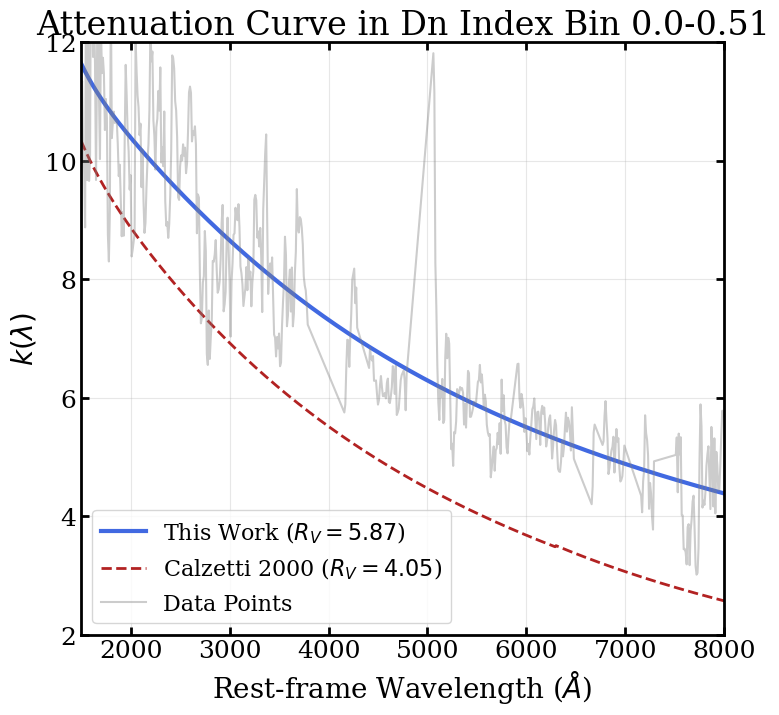

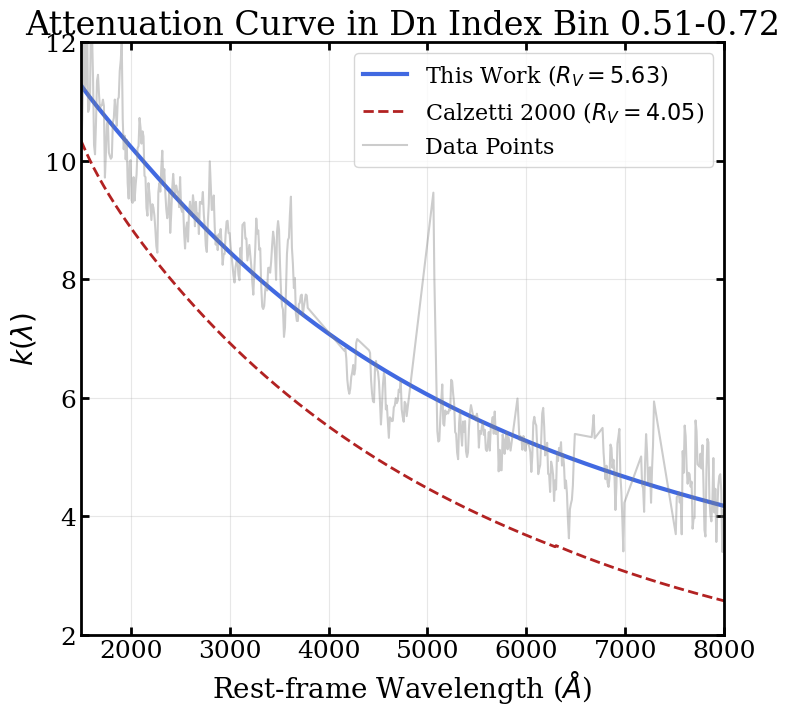

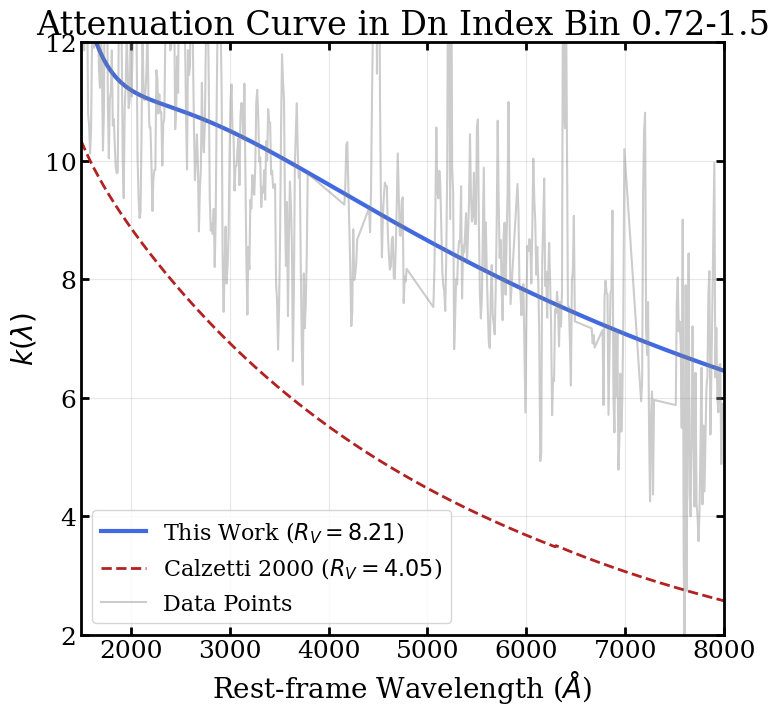

In [4]:
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

k_final_list=[]


for dn_bin_index in range(len(dn_index_conditions)):
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[dn_bin_index]

    wave = np.array(common_wavelength)
    Q_lambda = np.array(effective_attenuation_curve)

    mask_regions = [
        (3800,4150),
        (4300, 4400),  # Ca II H+K
        (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
        (5850,5900),
        (6500, 6650),  # H-alpha (6563) + [NII]
        (6700, 6760) ,  # [SII] Doublet
        (7000,7150),
        (7300,7500)
    ]
    is_continuum = np.ones_like(wave, dtype=bool)
    for start, end in mask_regions:
        is_continuum &= ~((wave >= start) & (wave <= end))

    valid_data = np.isfinite(Q_lambda) & np.isfinite(wave)
    is_continuum &= valid_data

    microns= wave / 10000.0
    x_wavenumber = 1.0 / microns

    fit_mask = (wave > 1250) & (wave < 8000) & is_continuum

    popt_raw, pcov = curve_fit(poly_model, microns[fit_mask], Q_lambda[fit_mask])

    a_intercept = popt_raw[0]  # 常数项
    b_term = popt_raw[1]
    c_term = popt_raw[2]
    d_term = popt_raw[3]

    C_shift = a_intercept

    Q_smooth = poly_model(microns, *popt_raw)
    A_lambda = Q_smooth - C_shift

    tau_B = poly_model(0.4400, *popt_raw) - C_shift
    tau_V = poly_model(0.5500, *popt_raw) - C_shift

    delta_tau = tau_B - tau_V
    Rv_measured = tau_V / delta_tau

    k_final = A_lambda / delta_tau
    k_final_list.append(k_final)

    fig, ax = plt.subplots(figsize=(8,7.5))
    k_calzetti = calzetti_2000_law(wave)
    ax.plot(wave, k_final, color='royalblue', lw=3, label=f'This Work ($R_V={Rv_measured:.2f}$)')
    ax.plot(wave, k_calzetti, color='firebrick', ls='--', lw=2, label='Calzetti 2000 ($R_V=4.05$)')

    k_data_scaled = (Q_lambda - C_shift) / delta_tau
    ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.4, label='Data Points')

    ax.axhline(0, color='black', lw=0.5, ls='-')
    ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=20)
    ax.set_ylabel(r'$k(\lambda)$', fontsize=20)
    ax.set_title(r'Attenuation Curve in Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', fontsize=24)
    ax.legend(fontsize=16)
    ax.set_xlim(1500, 8000)
    ax.set_ylim(bottom=2, top=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("attenuation_curve_DnBin_"+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}'+".pdf")
    plt.show()




In [ ]:

# ==========================================
# 假设变量 (请确保这些数据已加载)
# ==========================================
wave = np.array(averager.common_wavelength)  # Angstrom
Q_curve = np.array(effective_attenuation_curve)

# 定义强发射线区域 (会被排除在计算之外)
mask_regions = [

    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))

# 排除数据中的 NaN 和 Inf
valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
is_continuum &= valid_data

# ==========================================
# 1. 拟合多项式以寻找截距 (Intercept)
# ==========================================
# 转换波长到微米，并计算波数 x = 1/lambda
microns = wave / 10000.0
x_wavenumber = 1.0 / microns

# 拟合范围 Mask
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum

# 定义多项式模型 (关于 1/lambda)
# k(lambda) = a + b(1/l) + c(1/l)^2 + d(1/l)^3
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# 进行拟合
popt_raw, pcov = curve_fit(poly_model, microns[fit_mask], Q_curve[fit_mask])

# 提取参数
a_intercept = popt_raw[0]  # 常数项
b_term = popt_raw[1]
c_term = popt_raw[2]
d_term = popt_raw[3]

print("=== Polynomial Fit Parameters (Raw) ===")
print(f"a (Intercept at 1/lam=0) = {a_intercept:.4f}")
print(f"b = {b_term:.4f}")
print(f"c = {c_term:.4f}")
print(f"d = {d_term:.4f}")

# ==========================================
# 2. 强制无穷长波处为 0
# ==========================================
# 物理假设: A(lambda -> inf) = 0
# 这意味着我们需要减去多项式的常数项 a
C_shift = a_intercept

print(f"\n[Strategy] Force A(inf) = 0")
print(f"Zero-point Shift applied: {C_shift:.4f}")

# 生成平滑的、去基底的 A(lambda)
# 注意：这等同于只保留 b*x + c*x^2 + d*x^3
Q_smooth = poly_model(microns, *popt_raw)
A_lambda = Q_smooth - C_shift

# ==========================================
# 3. 计算 k(lambda) 和 Rv
# ==========================================
# 计算 B 和 V 波段的光学深度 (已减去 C_shift)
# 4400A = 0.44um, 5500A = 0.55um
tau_B = poly_model(0.4400, *popt_raw) - C_shift
tau_V = poly_model(0.5500, *popt_raw) - C_shift

# 计算分母：色余 (Slope)
delta_tau = tau_B - tau_V

# 计算 Rv
# Rv = A(V) / (A(B) - A(V))
Rv_measured = tau_V / delta_tau

# 计算最终曲线 k(lambda)
# k = A(lambda) / E(B-V)
k_final = A_lambda / delta_tau

print("-" * 30)
print(f"A(V) [ln scale] = {tau_V:.4f}")
print(f"E(B-V) [ln scale] = {delta_tau:.4f}")
print("-" * 30)
print(f"Measured R_V = {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 4. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(8,7.5))

# Calzetti 2000 参考线
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_calzetti = calzetti_2000_law(wave)

# 绘制你的曲线
ax.plot(wave, k_final, color='royalblue', lw=3, label=f'This Work ($R_V={Rv_measured:.2f}$)')
# 绘制 Calzetti
ax.plot(wave, k_calzetti, color='firebrick', ls='--', lw=2, label='Calzetti 2000 ($R_V=4.05$)')

# 绘制数据背景 (同样应用 Shift 和 Scaling)
k_data_scaled = (Q_curve - C_shift) / delta_tau
ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.4, label='Data Points')

# 辅助线：标出 Zero
ax.axhline(0, color='black', lw=0.5, ls='-')

ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=20)
ax.set_ylabel(r'$k(\lambda)$', fontsize=20)
ax.set_title(r'Attenuation Curve (Forced $A_{\infty}=0$)', fontsize=24)
ax.legend(fontsize=16)
ax.set_xlim(1500, 8000)
ax.set_ylim(bottom=2, top=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("attenuation_curve_forced_Ainf0.pdf")
plt.show()

# ==========================================
# 5. 输出最终公式系数
# ==========================================
# 最终公式系数需要除以 delta_tau (归一化)
# 且常数项 a 已经变成了 0
final_b = b_term / delta_tau
final_c = c_term / delta_tau
final_d = d_term / delta_tau

print("\n=== Final k(lambda) Formula Coefficients ===")
print("k(lambda) = b*(1/x) + c*(1/x)^2 + d*(1/x)^3  [x in microns]")
print(f"b = {final_b:.4f}")
print(f"c = {final_c:.4f}")
print(f"d = {final_d:.4f}")



print("\n" + "="*40)
print("     DERIVING FINAL NORMALIZED FORMULA")
print("="*40)

# 1. 提取原始系数 (Raw Coefficients form Q)
# Q(x) = a + b*x + c*x^2 + d*x^3
a_raw, b_raw, c_raw, d_raw = popt_raw

# 2. 应用 Zero-Point Shift (强制 Inf=0)
# A(x) = Q(x) - a_raw = 0 + b*x + c*x^2 + d*x^3
# (常数项 a 被减掉了)

# 3. 计算归一化因子 (Scaling Factor)
# Calzetti 的 2.659 就是这个 S
S_factor = 1.0 / delta_tau

print(f"Your Scaling Factor (comparable to 2.659): {S_factor:.4f}")

# 4. 计算最终归一化后的系数
# k(x) = S * A(x) = S*b*x + S*c*x^2 + S*d*x^3
b_final = b_raw * S_factor
c_final = c_raw * S_factor
d_final = d_raw * S_factor

# 5. 计算你的 Rv
# Rv = k(V)
x_V = 1.0 / 0.55  # V-band wavenumber
Rv_final = b_final*x_V + c_final*(x_V**2) + d_final*(x_V**3)

# ==========================================
# 输出 1: 标准多项式形式 (最推荐，也是最通用的)
# ==========================================
print("\n[Form 1] Standard Polynomial Form:")
print("k(lambda) = b*(1/lam) + c*(1/lam)^2 + d*(1/lam)^3")
print(f"Where lam is in microns.")
print("-" * 30)
print(f"b = {b_final:.4f}")
print(f"c = {c_final:.4f}")
print(f"d = {d_final:.4f}")
print("-" * 30)
print(f"Derived R_V = {Rv_final:.4f}")


# ==========================================
# 输出 2: Calzetti 风格形式 (分离 Rv)
# ==========================================
# Calzetti 的形式通常是: k(lam) = Curve_Shape(lam) + Rv
# 其中 Curve_Shape(V) 必须等于 0 (或者接近0)
# 我们把公式改写为: k(lam) = [ k(lam) - Rv ] + Rv

# 新的常数项 (吸收掉 Rv)
# Poly_Reddening(x) = -Rv + b_final*x + ...
const_reddening = -Rv_final

print("\n[Form 2] Calzetti-Style (Separated Rv):")
print(f"k(lambda) = D + {b_final:.3f}*(1/lam) {c_final:+.3f}*(1/lam)^2 {d_final:+.3f}*(1/lam)^3 + R_V")
print(f"Fixed Constant D = {const_reddening:.4f}")
print(f"Measured R_V = {Rv_final:.4f}")

# 验证一下 V 波段
val_V_check = const_reddening + b_final*(1/0.55) + c_final*(1/0.55)**2 + d_final*(1/0.55)**3 + Rv_final
print(f"Validation Check at V-band (Should be {Rv_final:.4f}): {val_V_check:.4f}")

# ==========================================
# 6. 画出最终公式曲线 (验证)
# ==========================================
x_plot = 1.0 / (wave / 10000.0)
k_formula = b_final*x_plot + c_final*(x_plot**2) + d_final*(x_plot**3)



x_per_micron = 10000.0 / wave

# 你的曲线 (归一化到 V 波段)
# 理论上 Rv_measured = k_final 在 5500A 的值
# 所以 y_user = k_final / Rv_measured
idx_V = (np.abs(wave - 5500)).argmin()
Rv_check = k_final[idx_V]
y_user = k_final / Rv_check

# ==========================================
# 1. 定义标准参考曲线模型
# ==========================================


# ==========================================
# 2. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 7.5)) # 类似论文的长宽比

# 生成 X 轴网格 (用于绘制光滑的标准曲线)
x_grid = np.linspace(1.0, 8.2, 500)

# --- 绘制标准曲线 ---
# 1. Calzetti (Cyan dashed)
y_calzetti = get_calzetti_curve(x_grid)
ax.plot(x_grid, y_calzetti, color='cyan', linestyle='--', linewidth=1.5, label='Calzetti (SB)')

# 2. Milky Way (Purple dotted) - With Bump
y_mw = get_mw_ccm89(x_grid, Rv=3.1)
ax.plot(x_grid, y_mw, color='purple', linestyle=':', linewidth=1.5, label='MW ($R_V=3.1$)')

# 3. SMC (Magenta/Pink dashed) - Steep, no bump
y_smc = get_smc_pei92(x_grid)
ax.plot(x_grid, y_smc, color='magenta', linestyle='--', linewidth=1.5, label='SMC (Pei 92)')

# --- 绘制你的曲线 (Bold Solid Line) ---
# 截取 x 在 [2, 8.2] 范围内的数据
mask_plot = (x_per_micron >= 1.0) & (x_per_micron <= 8.2)

# 为了视觉效果平滑，你可以使用拟合后的公式画图，也可以直接画平滑后的数据
# 这里画你的拟合公式 (popt_raw from previous step)，这样最干净
# 假设 popt_raw 是之前算好的
# k(lam) = b/lam + c/lam^2 ...
# A/Av = k(lam) / Rv
# 我们直接用你的 y_user (实测数据) 也可以，如果噪点不多
ax.plot(x_per_micron[mask_plot], y_user[mask_plot],
        color='blue', linewidth=4, alpha=0.9,
        label=f'This Work ($R_V={Rv_measured:.2f}$)')

# 也可以加上误差阴影 (模拟效果，如果你有 error array 请替换)
# y_err = y_user[mask_plot] * 0.1
# ax.fill_between(x_per_micron[mask_plot], y_user[mask_plot]-y_err, y_user[mask_plot]+y_err,
#                 color='blue', alpha=0.15)


# --- 样式调整 (仿照截图) ---
ax.set_xlim(2.0, 8.2)
ax.set_ylim(1, 5)

# 坐标轴标签
ax.set_xlabel(r'$\lambda^{-1}$ [$\mu$m]$^{-1}$')
ax.set_ylabel(r'$A_{\lambda}/A_V$')

# 刻度设置
ax.tick_params(axis='both', which='major', labelsize=16, direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3)

# 强制 Y 轴从 1.5 开始，这意味我们只看 UV 部分
# 截图中的灰色区域/彩色区域可以通过 fill_between 添加，如果你有不同红移区间的 binning 结果

# 图例
ax.legend(fontsize=14, loc='upper left', frameon=False)

# 标题 (可选)
ax.set_title("Attenuation Curve Comparison")

plt.tight_layout()

plt.savefig("attenuation_curve_comparison.pdf")
plt.show()


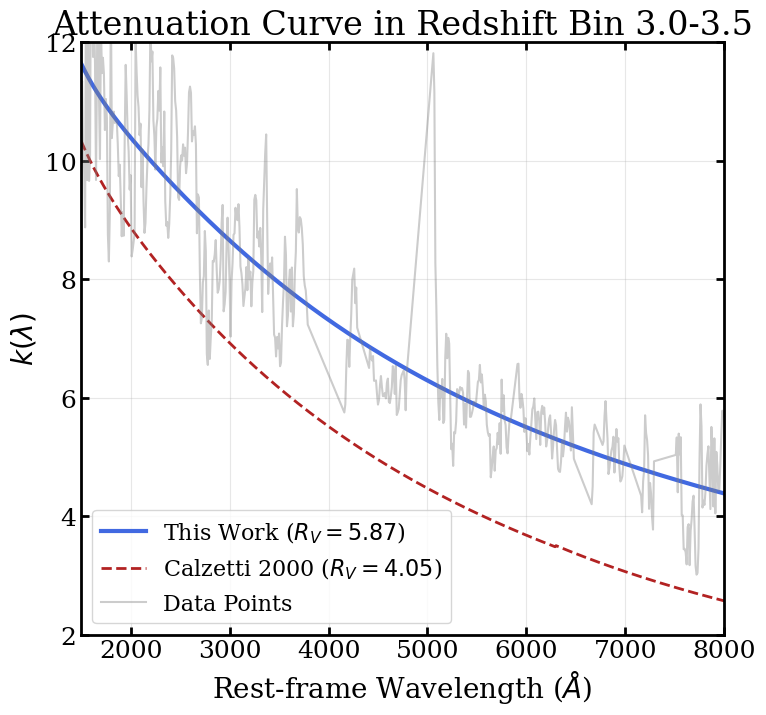

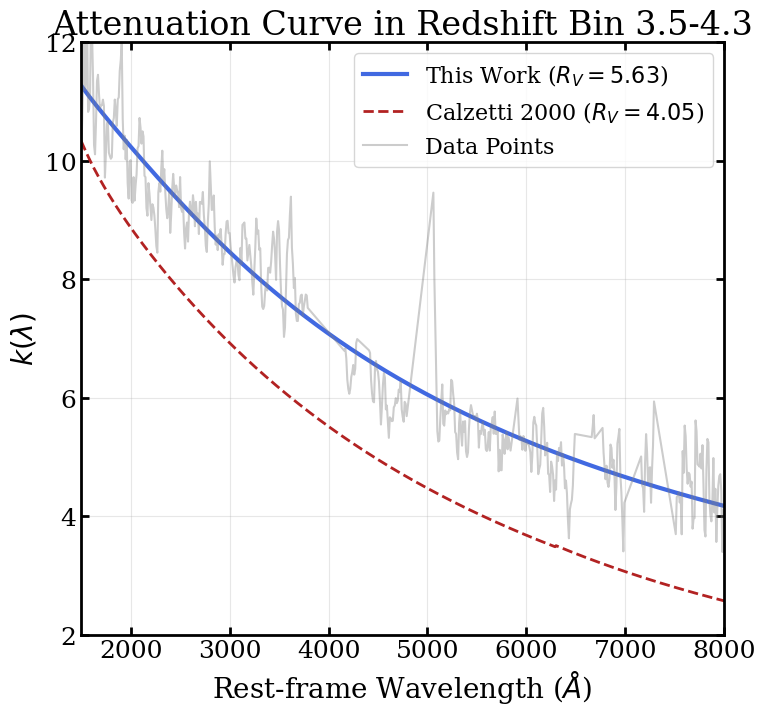

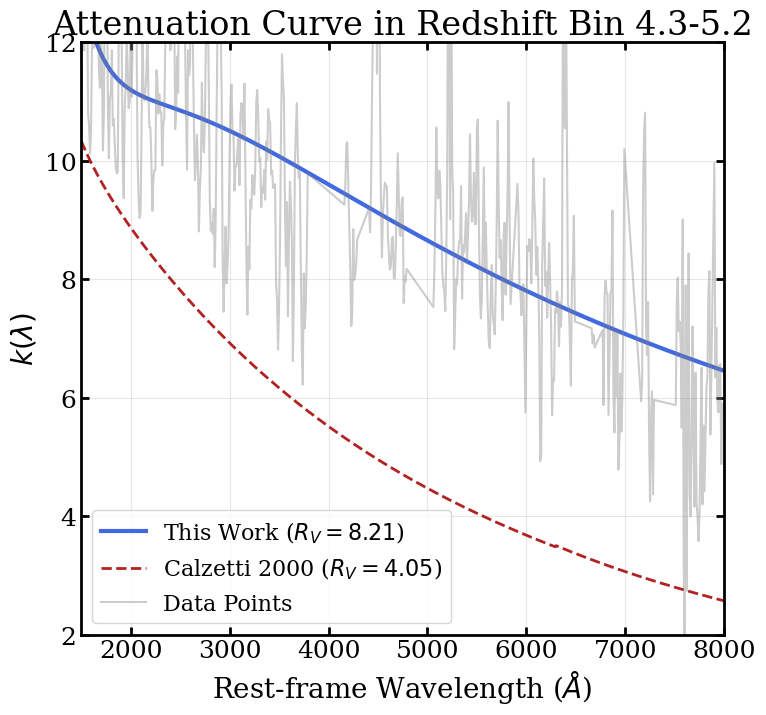

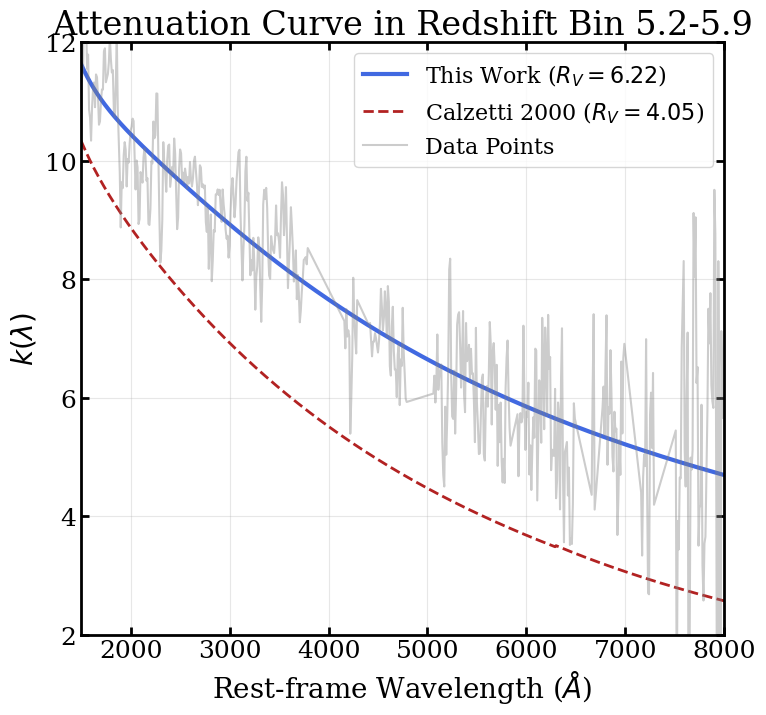

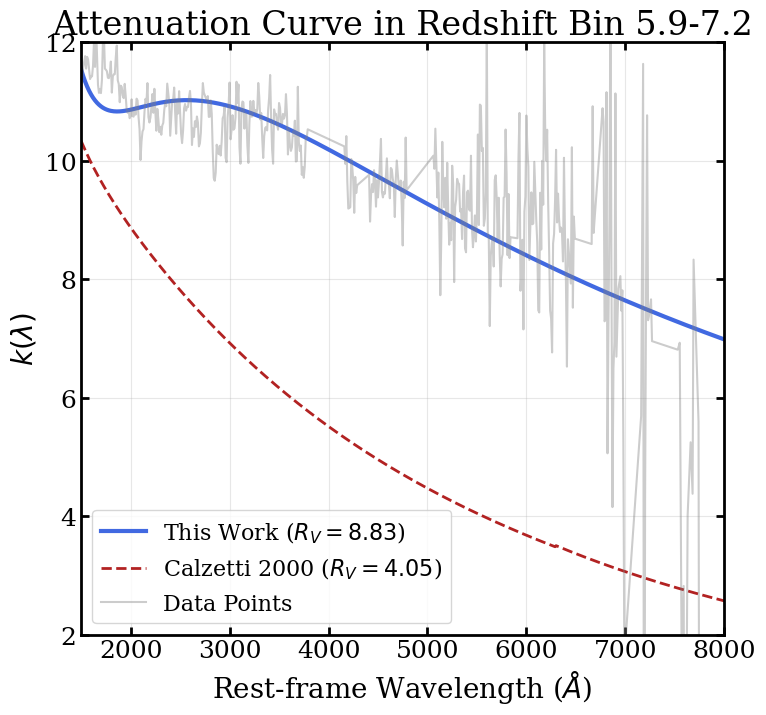

In [6]:
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

k_final_list=[]
redshift_conditions=np.array([[3,3.5],[3.5,4.3],[4.3,5.2],[5.2,5.9],[5.9,7.2]])
for redshift_bin_index in range(len(redshift_conditions)):
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[redshift_bin_index]

    wave = np.array(common_wavelength)
    Q_lambda = np.array(effective_attenuation_curve)

    mask_regions = [
        (3800,4150),
        (4300, 4400),  # Ca II H+K
        (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
        (5850,5900),
        (6500, 6650),  # H-alpha (6563) + [NII]
        (6700, 6760) ,  # [SII] Doublet
        (7000,7150),
        (7300,7500)
    ]
    is_continuum = np.ones_like(wave, dtype=bool)
    for start, end in mask_regions:
        is_continuum &= ~((wave >= start) & (wave <= end))

    valid_data = np.isfinite(Q_lambda) & np.isfinite(wave)
    is_continuum &= valid_data

    microns= wave / 10000.0
    x_wavenumber = 1.0 / microns

    fit_mask = (wave > 1250) & (wave < 8000) & is_continuum

    popt_raw, pcov = curve_fit(poly_model, microns[fit_mask], Q_lambda[fit_mask])

    a_intercept = popt_raw[0]  # 常数项
    b_term = popt_raw[1]
    c_term = popt_raw[2]
    d_term = popt_raw[3]

    C_shift = a_intercept

    Q_smooth = poly_model(microns, *popt_raw)
    A_lambda = Q_smooth - C_shift

    tau_B = poly_model(0.4400, *popt_raw) - C_shift
    tau_V = poly_model(0.5500, *popt_raw) - C_shift

    delta_tau = tau_B - tau_V
    Rv_measured = tau_V / delta_tau

    k_final = A_lambda / delta_tau
    k_final_list.append(k_final)

    fig, ax = plt.subplots(figsize=(8,7.5))
    k_calzetti = calzetti_2000_law(wave)
    ax.plot(wave, k_final, color='royalblue', lw=3, label=f'This Work ($R_V={Rv_measured:.2f}$)')
    ax.plot(wave, k_calzetti, color='firebrick', ls='--', lw=2, label='Calzetti 2000 ($R_V=4.05$)')

    k_data_scaled = (Q_lambda - C_shift) / delta_tau
    ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.4, label='Data Points')

    ax.axhline(0, color='black', lw=0.5, ls='-')
    ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=20)
    ax.set_ylabel(r'$k(\lambda)$', fontsize=20)
    ax.set_title(r'Attenuation Curve in Redshift Bin '+f'{redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', fontsize=24)
    ax.legend(fontsize=16)
    ax.set_xlim(1500, 8000)
    ax.set_ylim(bottom=2, top=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("attenuation_curve_RedshiftBin_"+f'{redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}'+".pdf")
    plt.show()

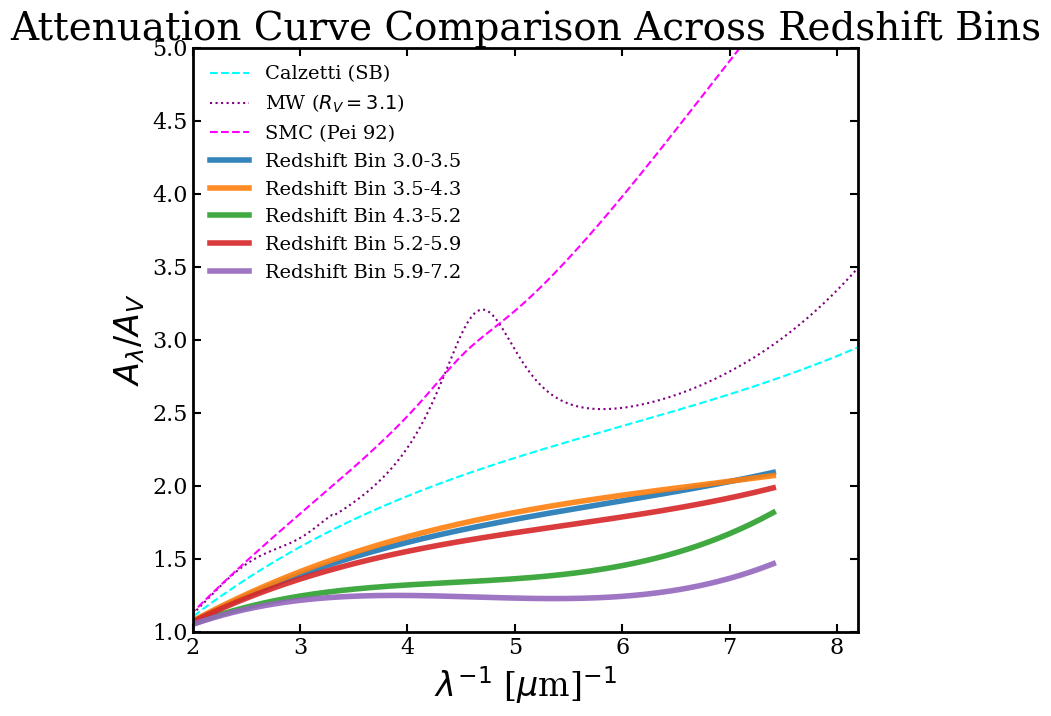

In [7]:
x_per_micron = 10000.0 / wave
fig,ax=plt.subplots(figsize=(8,7.5))

x_grid = np.linspace(1.0, 8.2, 500)

y_calzetti = get_calzetti_curve(x_grid)
ax.plot(x_grid, y_calzetti, color='cyan', linestyle='--', linewidth=1.5, label='Calzetti (SB)')

y_mw = get_mw_ccm89(x_grid, Rv=3.1)
ax.plot(x_grid, y_mw, color='purple', linestyle=':', linewidth=1.5, label='MW ($R_V=3.1$)')

y_smc = get_smc_pei92(x_grid)
ax.plot(x_grid, y_smc, color='magenta', linestyle='--', linewidth=1.5, label='SMC (Pei 92)')

mask_plot = (x_per_micron >= 1.0) & (x_per_micron <= 8.2)

for redshift_bin_index in range(len(redshift_conditions)):
    k_final = k_final_list[redshift_bin_index]
    idx_V = (np.abs(wave - 5500)).argmin()
    Rv_check = k_final[idx_V]
    y_user = k_final / Rv_check

    ax.plot(x_per_micron[mask_plot], y_user[mask_plot],
            linewidth=4, alpha=0.9,
            label=f'Redshift Bin {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}')
# ==========================================
ax.set_xlim(2.0, 8.2)
ax.set_ylim(1, 5)

ax.set_xlabel(r'$\lambda^{-1}$ [$\mu$m]$^{-1}$')
ax.set_ylabel(r'$A_{\lambda}/A_V$')
ax.tick_params(axis='both', which='major', labelsize=16, direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3)
ax.legend(fontsize=14, loc='upper left', frameon=False)
ax.set_title("Attenuation Curve Comparison Across Redshift Bins")
plt.tight_layout()
plt.savefig("attenuation_curve_comparison_redshift_bins.pdf")
plt.show()